In [193]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Figures for deck 5

One header per slide of the planned deck. Everything here is **figures only** — the
numbers and the argument live in `brand_consistency.ipynb`, `apple_brand_decay.ipynb`
and `docs/progress.md`. This notebook exists to produce the images.

Every figure is written to `figs/deck5/<slide>_<name>.png` so it can be dropped straight
into PowerPoint. Set `SAVE = False` below to skip writing files.

Palette is reused verbatim from the other two notebooks so all three read as one system.

## Running order — the distilled deck

24 figures is too many to present. These **13** carry the argument; everything else is
backup. Each line says what the slide claims.

| # | figure | the one sentence |
|---|---|---|
| 1 | `s04_setup` | what we ran: 8 models x 4 contracts, 9900 comparisons each |
| 2 | `s05_adherence_trend` | **does it obey? by contract and by model size** |
| 2b | `s05_what_moves` | **what else it broke: a ram contract moves everything** |
| 3 | `s06_brand_corr` | a contract that never mentions brand still reorders the brands |
| 4 | `s07_one_brand` | it is **one** brand — drop Apple and the rest are stable (r = +0.92) |
| 5 | `s08_modelfree` | the fact needs no model: 87% → 35% raw win rate |
| 6 | `s10_c6_ordinal_cells` | the mechanism, in ranks only (magnitudes are not trustworthy) |
| 7 | `s10_c6_ordinal_feasible` | even Apple's best *compliant* laptop is demoted |
| 8 | `s10b_priority` | **the deeper finding: a priority list, not a utility** |
| 9 | `s10b_additivity_broken` | the additive model's own parameter moves 8x — it is the wrong model |
| 10 | `s10b_contract_power` | a contract beats a *tendency* completely, a *veto* only partly |
| 11 | `s11_leakage` | one number: a ram contract **cancels** the brand preference (−0.94) |
| 12 | `s12_saturation` | method health: the measurement is at its ceiling in 88-99% of rows |
| 13 | `s14_next_runs` | the 4 single contracts that would identify the interaction matrix |

**Backup, bring if asked:** `s04_itemset`, `s05_override`, `s05_adherence_scale`, `s05_dilution`,
`s06_brand_trajectories`, `s09_*` (the four rejected conjectures — the defence of slide 6),
`s10_c6_headline`, `s10_c6_grid`, `s10_c6_permodel`, `s11_contract_reading`,
`s12_gamma_vs_features`, `s12_bias_flips`, `s12_se_inflation`, `s12_additivity`,
`s13_robustness`, `s13_feasible_set`.

**Two health warnings for anything on a slide.**

1. **Never put a Bradley-Terry magnitude on a slide as if it were a trade-off.** The fitted
   brand weight triples depending only on which comparisons enter the fit. Ranks, win rates
   and override rates are safe; log-odds are not.
2. `s05_adherence_scale` ("+13 log-odds") and `s12_additivity` ("additivity holds") are both
   **superseded** by slide 10b. They are kept because the diagnostics are still useful, but
   do not present them as headline claims.

In [194]:
import json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

SAVE = True
FIGDIR = "figs/deck5"
os.makedirs(FIGDIR, exist_ok=True)

BASE = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
OTHER = ["ASUS", "Dell", "HP", "Lenovo"]
SC = ["13-inch", "14-inch", "16-inch"]
RM = ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]
SIZES = {"qwen": ["0.5", "7", "32", "72"], "gemma": ["1", "4", "12", "27"]}
ALL = [(f, s) for f in SIZES for s in SIZES[f]]
# qwen-0.5B is noise on every measure (brand_consistency.ipynb) - excluded from stats,
# but kept in the coverage/diagnostic figures where its being noise is the point.
REAL = [("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in SIZES["gemma"]]
def lbl(f, s): return f"{f}-{s}B"

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834"}
SATISFY, VIOLATE, GAMMA_C = "#2a78d6", "#e34948", "#52514e"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list("bl_gy_rd", [VIOLATE, "#f0efec", SATISFY])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
    "font.size": 10, "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 220)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig

In [195]:
def load():
    """Scores + the constraint DICT per run (2026-08-10 config schema)."""
    R, C_ = {}, {}
    for b in BASE:
        for run in sorted(os.listdir(b)):
            cp = os.path.join(b, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            R[key] = pd.read_csv(os.path.join(b, run, "scores.csv"))
            C_[key] = c["constraints"]
    return R, C_


def satisfies(constraints, **features):
    return all(features[f] == lvl for f, lvl in constraints.items())


def fit_bt(df, feats=("brand", "screen", "ram")):
    """Sum-to-zero feature Bradley-Terry with a positional-bias intercept."""
    y = (df.score_a - df.score_b).values
    cs, names = [np.ones(len(df))], ["gamma"]
    for f in feats:
        for l in LEVELS[f]:
            if l not in set(df["a_" + f]) | set(df["b_" + f]):
                continue
            cs.append((df["a_" + f].values == l).astype(float)
                      - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cs)
    w, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = dict(zip(names, w))
    for f in feats:
        ks = [k for k in names if k.startswith(f + "_")]
        m = np.mean([out[k] for k in ks])
        for k in ks:
            out[k] -= m
    out["r2"] = 1 - (y - X @ w).var() / y.var()
    return out


def fit_full(df):
    """FULL parameterization: one free weight per laptop (45), no additivity assumed."""
    y = (df.score_a - df.score_b).values
    la = df.a_brand + "-" + df.a_screen + "-" + df.a_ram
    lb = df.b_brand + "-" + df.b_screen + "-" + df.b_ram
    items = sorted(set(la) | set(lb))
    idx = {it: i for i, it in enumerate(items)}
    X = np.zeros((len(df), len(items) + 1))
    X[:, 0] = 1.0
    r = np.arange(len(df))
    X[r, 1 + la.map(idx).values] = 1.0
    X[r, 1 + lb.map(idx).values] = -1.0
    w, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = w[1:] - w[1:].mean()
    return {"u": dict(zip(items, u)), "gamma": w[0],
            "r2": 1 - (y - X @ w).var() / y.var()}


def fvec(w, feat):
    return np.array([w[f"{feat}_{l}"] for l in LEVELS[feat]])

def bvec(w):
    return fvec(w, "brand")

def cell(df, screen, ram):
    """The 5 laptops sharing this (screen, ram): they differ ONLY in brand."""
    return df[(df.a_screen == screen) & (df.b_screen == screen)
              & (df.a_ram == ram) & (df.b_ram == ram)]

def item_utils(w):
    """Additive utility of all 45 laptops from the feature weights."""
    return {(b, s, r): w[f"brand_{b}"] + w[f"screen_{s}"] + w[f"ram_{r}"]
            for b in BRANDS for s in SC for r in RM}


RUNS, CONSTRAINTS = load()
W = {k: fit_bt(d) for k, d in RUNS.items()}
FULL = {k: fit_full(d) for k, d in RUNS.items()}
print(f"{len(RUNS)} runs loaded and fitted "
      f"({len({k[:2] for k in RUNS})} models x {len({k[2] for k in RUNS})} contracts)")

32 runs loaded and fitted (8 models x 4 contracts)


In [196]:
# Per-cell brand fits (5 laptops that differ only in brand) - used by slides 9, 10, 11.
cells = []
for fam, s in REAL:
    for c in CON:
        con = CONSTRAINTS[(fam, s, c)]
        for sc in SC:
            for rm in RM:
                v = bvec(fit_bt(cell(RUNS[(fam, s, c)], sc, rm), ("brand",)))
                cells.append(dict(fam=fam, size=s, model=lbl(fam, s), con=CLAB[c],
                                  screen=sc, ram=rm, apple=v[1],
                                  rank=1 + (v > v[1]).sum(),
                                  z=(v[1] - v.mean()) / v.std(ddof=0),
                                  spread=v.max() - v.min(),
                                  sat=satisfies(con, screen=sc, ram=rm) if con else None))
E = pd.DataFrame(cells)
print(f"{len(E)} within-cell brand fits")

252 within-cell brand fits


---
# Slide 4 — Setup

45 laptops (5 brands x 3 screens x 3 ram, full factorial), 4 contracts, 8 models.
One added sentence is the whole contract.

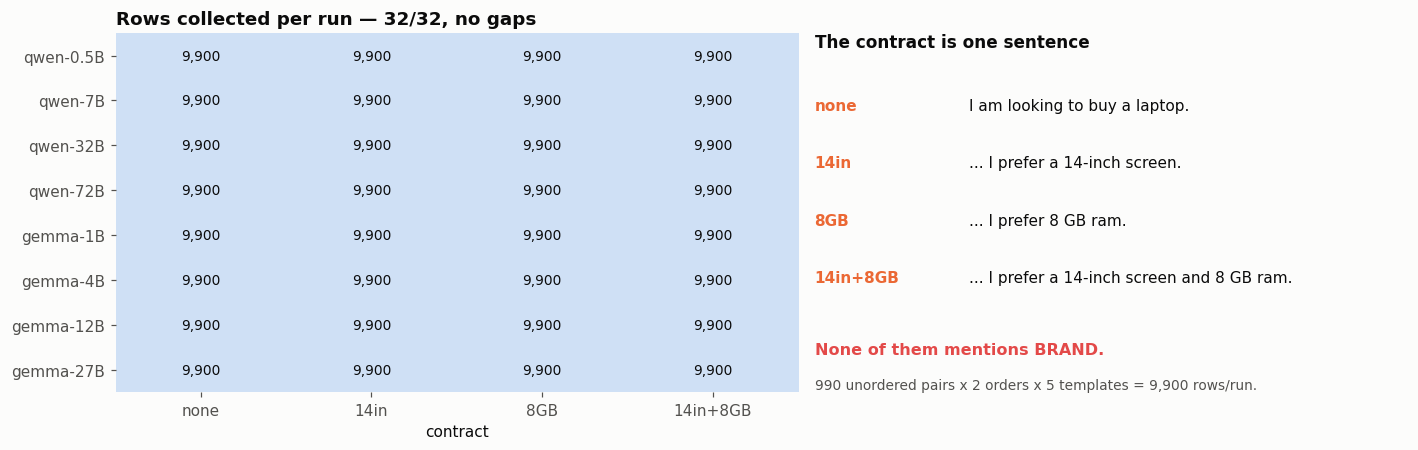

In [197]:
# Fig 4.1 - what was collected, and what the contract actually says.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
M = np.array([[len(RUNS[(f, s, c)]) if (f, s, c) in RUNS else 0 for c in CON] for f, s in ALL])
ax.imshow(np.where(M > 0, 1.0, 0.0), cmap=LinearSegmentedColormap.from_list(
    "cov", ["#f4f3f0", "#cfe0f5"]), vmin=0, vmax=1, aspect="auto")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:,}", ha="center", va="center", fontsize=9, color=INK)
ax.set_xticks(range(4), cols)
ax.set_yticks(range(len(ALL)), [lbl(f, s) for f, s in ALL])
ax.set_title("Rows collected per run — 32/32, no gaps", loc="left", fontweight="bold")
ax.set_xlabel("contract")
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)

ax = axes[1]
ax.axis("off")
txt = [("none", "I am looking to buy a laptop."),
       ("14in", "... I prefer a 14-inch screen."),
       ("8GB", "... I prefer 8 GB ram."),
       ("14in+8GB", "... I prefer a 14-inch screen and 8 GB ram.")]
ax.text(0, 1.0, "The contract is one sentence", fontsize=11, fontweight="bold", va="top")
for i, (k, t) in enumerate(txt):
    y = 0.82 - i * 0.16
    ax.text(0, y, k, fontsize=10, fontweight="bold", color=FEATURE_COLOR["screen"], va="top")
    ax.text(0.26, y, t, fontsize=10, va="top", color=INK)
ax.text(0, 0.14, "None of them mentions BRAND.", fontsize=10.5, va="top",
        fontweight="bold", color=VIOLATE)
ax.text(0, 0.04, "990 unordered pairs x 2 orders x 5 templates = 9,900 rows/run.",
        fontsize=9, va="top", color=INK_MUTED)
fig.tight_layout()
save(fig, "s04_setup")
plt.show()

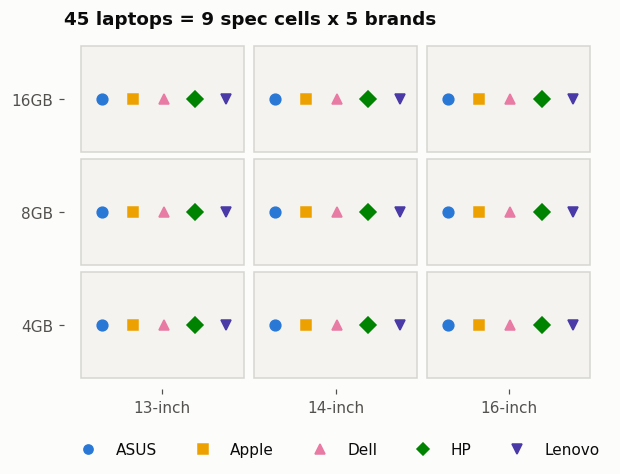

In [198]:
# Fig 4.2 - the item set. 3x3 spec cells, 5 brands in each.
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for i, rm in enumerate(RM):
    for j, sc in enumerate(SC):
        ax.add_patch(Rectangle((j, i), .94, .94, facecolor="#f4f3f0", edgecolor="#d6d5d1"))
        for k, b in enumerate(BRANDS):
            ax.plot(j + .12 + k * .18, i + .47, BRAND_MARKER[b], color=BRAND_COLOR[b], ms=7)
ax.set_xlim(-.1, 3.05); ax.set_ylim(-.1, 3.05)
ax.set_xticks([j + .47 for j in range(3)], SC)
ax.set_yticks([i + .47 for i in range(3)], RM)
ax.set_title("45 laptops = 9 spec cells x 5 brands", loc="left", fontweight="bold")
ax.grid(False)
ax.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b],
                          ls="", label=b) for b in BRANDS],
          ncol=5, loc="upper center", bbox_to_anchor=(.5, -.11), frameon=False)
for sp in ax.spines.values():
    sp.set_visible(False)
save(fig, "s04_itemset")
plt.show()

---
# Slide 5 — Does the model listen at all?

Contract adherence scales hard with size. And two constraints dilute each other.

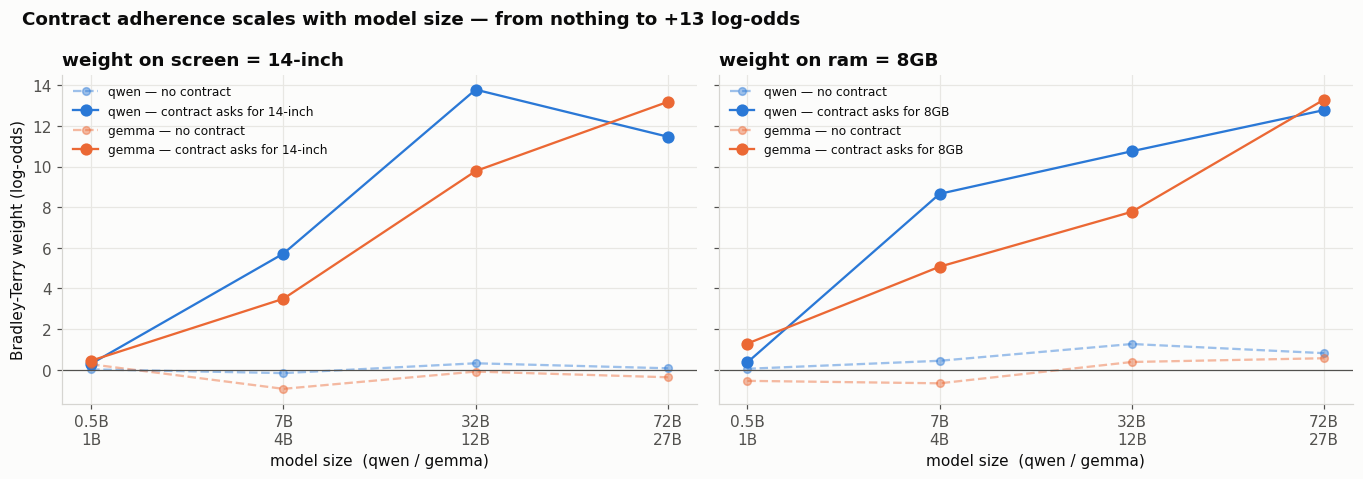

In [199]:
# Fig 5.1 - weight on the constrained level, before vs after the contract names it.
SINGLE = {"screen=14-inch": ("screen", "14-inch"), "ram=8GB": ("ram", "8GB")}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, (con, (f, l)) in zip(axes, SINGLE.items()):
    for fam in SIZES:
        xs = SIZES[fam]
        base = [W[(fam, s, "none")][f"{f}_{l}"] for s in xs]
        got = [W[(fam, s, con)][f"{f}_{l}"] for s in xs]
        ax.plot(range(len(xs)), base, "--o", color=FAM_COLOR[fam], alpha=.45, ms=5,
                label=f"{fam} — no contract")
        ax.plot(range(len(xs)), got, "-o", color=FAM_COLOR[fam], ms=7,
                label=f"{fam} — contract asks for {l}")
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_xticks(range(4), [f"{a}B\n{b}B" for a, b in zip(*SIZES.values())])
    ax.set_xlabel("model size  (qwen / gemma)")
    ax.set_title(f"weight on {f} = {l}", loc="left", fontweight="bold")
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("Bradley-Terry weight (log-odds)")
fig.suptitle("Contract adherence scales with model size — from nothing to +13 log-odds",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_adherence_scale")
plt.show()

### How to read Fig 5.3 — the override rate

**The pairs used.** Only the ones where the contract and the model's own taste **disagree**:
one laptop obeys the contract but has **less RAM**; the other ignores it and has **more RAM**.
A forced trade — you cannot have both.

**Bar height** = how often the model picks the *obedient* one.

| | meaning |
|---|---|
| 0% | always keeps the extra RAM, ignores the request |
| 50% (dashed) | coin flip |
| 100% | always does what it was asked |

**Right panel** is just the `8GB` bars redrawn against model size.

**Careful — this is the hardest possible test.** RAM is the models' strongest preference
(the veto, Fig 10b.1), so every conflict here pits the contract against the thing the model
wants most. A low bar means *"this model will not give up RAM"*, **not** *"this model ignores
instructions"* — where nothing has to be sacrificed, even gemma-1B complies 97-100%.

Brand and screen are left free inside these pairs, so this figure cannot say whether the
contract moved only the feature it named. **Fig 5.4 answers that.**

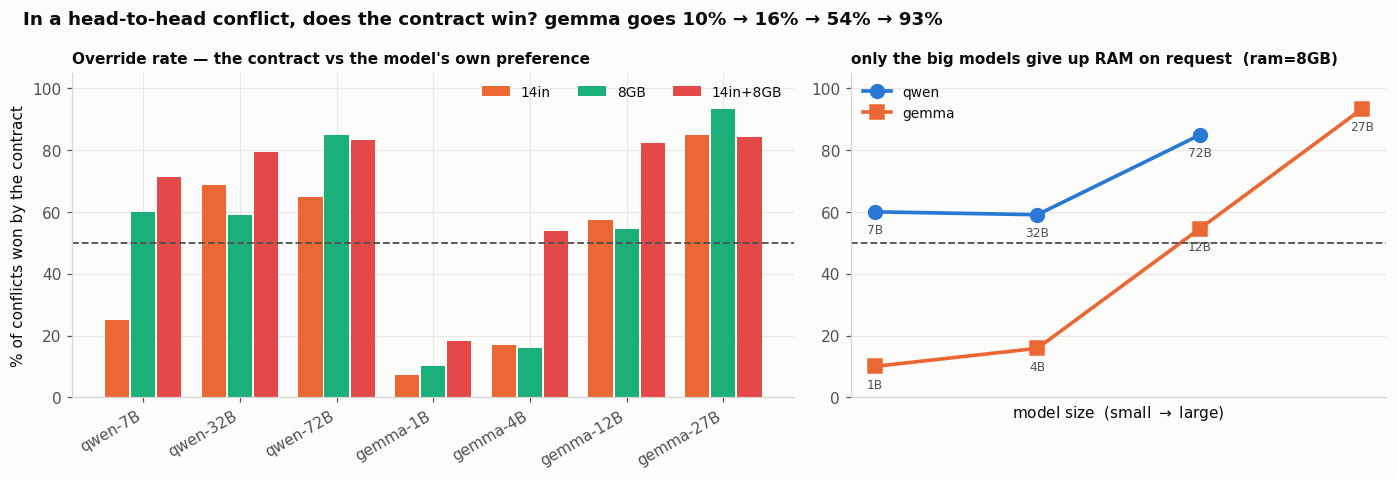

In [200]:
# Fig 5.3 - adherence measured as a BEHAVIOUR, not as a weight.
# READ WITH Fig 5.4. This looks ONLY at the conflict set, so on its own it cannot
# separate 'the contract promoted the feature it named' from 'the contract changed
# everything'. Fig 5.4 is the one that answers that.
# The weight in Fig 5.1 is a log-odds, and we now know log-odds magnitudes are not
# trustworthy here. This asks a question that cannot be inflated by the scale:
# when the contract and the model's OWN preference point at different laptops,
# how often does the contract win?
RORD = {"4GB": 0, "8GB": 1, "16GB": 2}

def complies(d, con, side):
    ok = np.ones(len(d), bool)
    for f, lvl in con.items():
        ok &= (d[f"{side}_{f}"] == lvl).values
    return ok

def winrate(d, mask, a_is_candidate):
    if mask.sum() == 0:
        return np.nan
    m, p = (d.score_a - d.score_b).values[mask], a_is_candidate[mask]
    return 100 * float(np.mean(np.where(p, m > 0, m < 0)))

rows = []
for fam, s in REAL:
    r = {"model": lbl(fam, s), "fam": fam, "size": float(s)}
    for c in CON[1:]:
        d, con = RUNS[(fam, s, c)], CONSTRAINTS[(fam, s, c)]
        ca, cb = complies(d, con, "a"), complies(d, con, "b")
        ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
        # conflict set: exactly one complies, and it is the one with LESS ram
        K = ((ca & ~cb) & (ra < rb)) | ((cb & ~ca) & (rb < ra))
        r[CLAB[c]] = winrate(d, K, ca)
    rows.append(r)
OVR = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4),
                         gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
x = np.arange(len(OVR))
for i, c in enumerate(cols[1:]):
    ax.bar(x + (i - 1) * .27, OVR[c], .25, label=c,
           color=[FEATURE_COLOR["screen"], FEATURE_COLOR["ram"], VIOLATE][i])
ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
ax.set_xticks(x, OVR.model, rotation=30, ha="right")
ax.set_ylim(0, 105)
ax.set_ylabel("% of conflicts won by the contract")
ax.set_title("Override rate — the contract vs the model's own preference",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9, ncol=3)

ax = axes[1]
for fam, mk_ in [("qwen", "o"), ("gemma", "s")]:
    ss = OVR[OVR.fam == fam].sort_values("size")
    ax.plot(range(len(ss)), ss["8GB"], "-" + mk_, color=FAM_COLOR[fam], lw=2.4, ms=9,
            label=fam)
    for i, (_, rr) in enumerate(ss.iterrows()):
        ax.annotate(f"{rr['size']:g}B", (i, rr["8GB"]), textcoords="offset points",
                    xytext=(0, -14), ha="center", fontsize=8, color=INK_MUTED)
ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
ax.set_xticks([])
ax.set_ylim(0, 105)
ax.set_xlabel("model size  (small $\\rightarrow$ large)")
ax.set_title("only the big models give up RAM on request  (ram=8GB)",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.suptitle("In a head-to-head conflict, does the contract win? "
             "gemma goes 10% → 16% → 54% → 93%",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_override")
plt.show()

### How to read Fig 5.4 — what the contract moves

**One bar = one question.** Take pairs of laptops that differ in **exactly one** feature and
are identical on the other two, then ask how often the model picks the "better" one:

| bar | pairs used | "better" = |
|---|---|---|
| ram | same brand, same screen | more RAM |
| screen | same brand, same RAM | bigger screen |
| brand | same screen, same RAM | Apple |

Grey = no contract (the same baseline in all three panels). Coloured = with that contract.
Dots = the 7 models individually. 50% = the feature decides nothing.

**The tricky part.** "Better" always means the model's **own** taste — never what the
contract asked for. So a drop means two different things:

- on a **(NAMED)** feature, a drop is *the contract working* — under `14in` the bar measures
  "bigger screen wins", and the contract pushes against it;
- on a feature the contract never mentioned, a drop is a **side effect**.

**The story.** `14in`: screen −30, ram −2, brand −4 → surgical. `8GB`: ram −17, and screen
and brand also −17, though nothing asked about them → global.

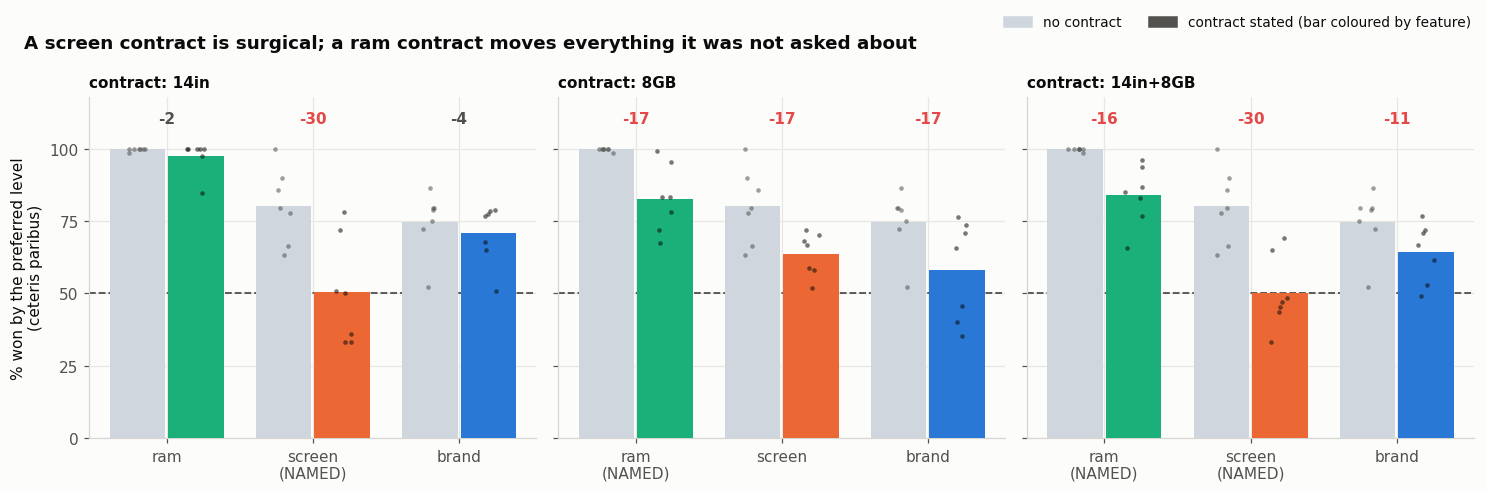

mean change from 'no contract' (percentage points):
contract   ram  screen  brand
    14in  -2.4   -29.9   -4.1
     8GB -17.1   -16.7  -16.6
14in+8GB -15.9   -30.1  -10.5


In [201]:
# Fig 5.4 - what the contract ACTUALLY moves. Fig 5.3 only looks at the conflict set,
# so on its own it cannot tell "the contract promoted the feature it named" apart from
# "the contract changed everything". This does: measure all three features ceteris
# paribus - pairs that differ in ONE feature and are tied on the other two.
#   ram    : % where MORE ram wins        screen : % where the BIGGER screen wins
#   brand  : % where Apple wins           50% = the feature decides nothing
# 90 ordered pairs x 5 templates = 450 rows per feature, per model, per contract.
def only_one(d, feat):
    others = [f for f in ("brand", "screen", "ram") if f != feat]
    m = (d[f"a_{feat}"] != d[f"b_{feat}"]).values.copy()
    for o in others:
        m &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    return m

SORD = {"13-inch": 0, "14-inch": 1, "16-inch": 2}
rows = []
for fam, s in REAL:
    for c in CON:
        d = RUNS[(fam, s, c)]
        pref = {"ram": d.a_ram.map(RORD).values > d.b_ram.map(RORD).values,
                "screen": d.a_screen.map(SORD).values > d.b_screen.map(SORD).values,
                "brand": (d.a_brand == "Apple").values}
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         **{f: winrate(d, only_one(d, f), pref[f])
                            for f in ("ram", "screen", "brand")}))
CP = pd.DataFrame(rows)
NAMED = {"14in": ["screen"], "8GB": ["ram"], "14in+8GB": ["screen", "ram"]}

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.3), sharey=True)
feats = ["ram", "screen", "brand"]
base = CP[CP.con == "none"].set_index("model")[feats]
rng = np.random.default_rng(0)
for ax, c in zip(axes, cols[1:]):
    cur = CP[CP.con == c].set_index("model")[feats].reindex(base.index)
    x = np.arange(3)
    ax.bar(x - .2, base.mean(), .38, color="#cfd6de", zorder=3)
    ax.bar(x + .2, cur.mean(), .38, zorder=3, color=[FEATURE_COLOR[f] for f in feats])
    for j, f in enumerate(feats):                       # the 7 models, so the mean is honest
        ax.scatter(np.full(7, j - .2) + rng.uniform(-.06, .06, 7), base[f], s=9,
                   color=INK_MUTED, alpha=.55, zorder=5, linewidths=0)
        ax.scatter(np.full(7, j + .2) + rng.uniform(-.06, .06, 7), cur[f], s=9,
                   color=INK, alpha=.55, zorder=5, linewidths=0)
        d = cur[f].mean() - base[f].mean()
        ax.text(j, 109, f"{d:+.0f}", ha="center", fontsize=10, fontweight="bold",
                color=VIOLATE if abs(d) > 10 else INK_MUTED)   # fixed height: the bar
                # tops differ per panel and the per-model dots sit right above them
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
    ax.set_xticks(x, [f + ("\n(NAMED)" if f in NAMED[c] else "") for f in feats])
    ax.set_ylim(0, 118)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_title(f"contract: {c}", loc="left", fontweight="bold", fontsize=10)
axes[0].set_ylabel("% won by the preferred level\n(ceteris paribus)")
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#cfd6de"),
                    Rectangle((0, 0), 1, 1, color=INK_MUTED)],
           labels=["no contract", "contract stated (bar coloured by feature)"],
           loc="upper right", ncol=2, frameon=False, fontsize=9,
           bbox_to_anchor=(.995, 1.045))
fig.suptitle("A screen contract is surgical; a ram contract moves everything it was "
             "not asked about", x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_what_moves")
plt.show()

print("mean change from 'no contract' (percentage points):")
print(pd.DataFrame([dict(contract=c, **{f: (CP[CP.con == c].set_index("model")[f]
                                            - base[f]).mean() for f in feats})
                    for c in cols[1:]]).round(1).to_string(index=False))

### How to read Fig 5.5 — adherence

Fig 5.4's measurement, in Fig 5.3's layout.

**Which pairs.** Laptops that differ **only** in the feature the contract named, where one has
the asked-for level and the other does not. Everything else is identical.

**Height** = how often the model picks the laptop the contract asked for.
**50% = the contract changed nothing** (that is the measured no-contract value, not a
convention: the asked-for level beats one neighbour and loses to the other).
**100% = the contract always decides.**

**Bars**: solid = a single contract, hatched = the same feature under the double contract
`14in+8GB`. Orange = screen, green = ram. **Right two panels**: the same numbers against
model size, one per family.

**Three things to look for**

1. **Screen is obeyed harder than ram** — 88% vs 75%. Asking for a screen size is easy;
   asking the model to give up RAM is not.
2. **Adherence grows with size** — clearest in gemma (ram: 55 → 51 → 75 → 92).
3. **Two requests dilute each other** — the hatched bars sit below the solid ones,
   ram worst (75% alone → 67% under the double).

**Do not read qwen-0.5B as obedient.** It goes 49 → 95 on ram, better than qwen-32B. It has
no preference of its own, so any nudge decides. Compliance without a competing preference is
not adherence.

/tmp/ipykernel_1276977/1779315823.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(range(len(sub)), sub[sname], "-o", ms=7, lw=2.2,
/tmp/ipykernel_1276977/1779315823.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(range(len(sub)), sub[sname], "-o", ms=7, lw=2.2,


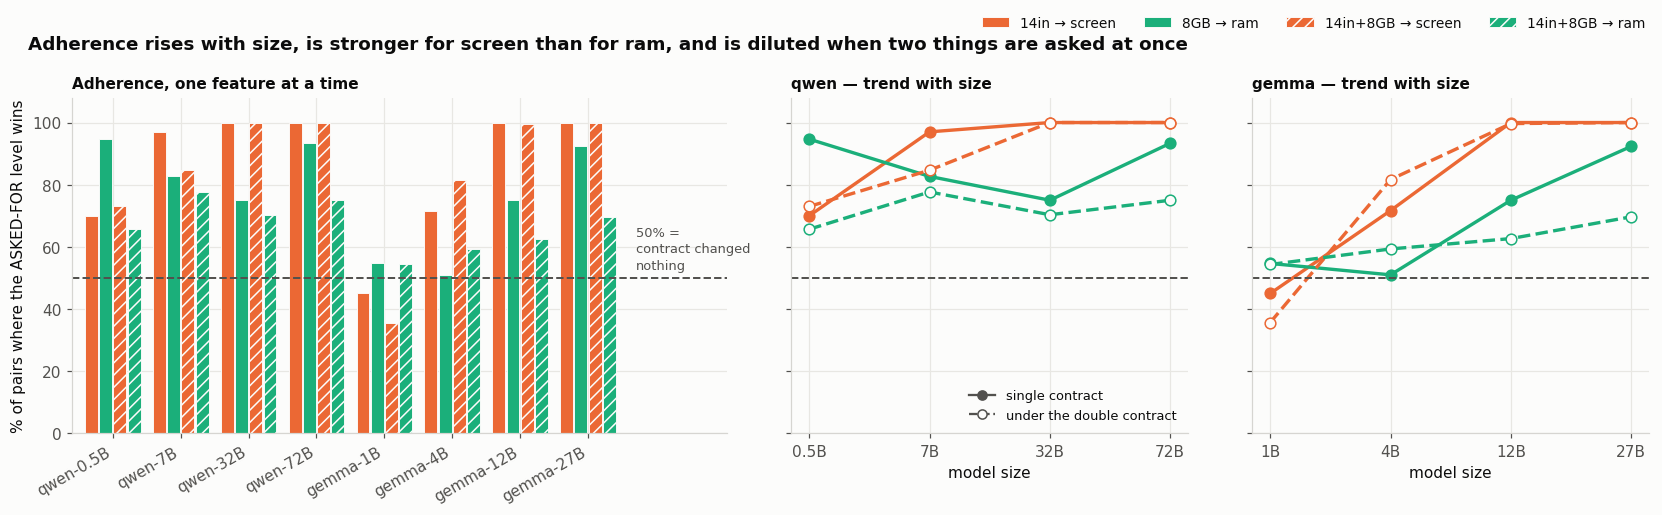

mean over the 7 models with real signal (qwen-0.5B excluded):
tag                baseline  contract
series                               
14in → screen          51.2      87.7
8GB → ram              50.3      74.9
14in+8GB → screen      51.2      86.0
14in+8GB → ram         50.3      67.0

qwen-0.5B is the odd one out (ram 49.3 -> 94.7). It has no competing preference of
its own, so a weak instruction decides by default. That is not adherence.


In [202]:
# Fig 5.5 - ADHERENCE: Fig 5.4's ceteris-paribus measurement, in Fig 5.3's layout.
# Pairs that differ ONLY in the named feature, where exactly one laptop has the level the
# contract asked for. Height = how often THAT laptop wins.
#   50% = the contract changed nothing   100% = the contract always decides
# The 50% line is not a convention: with no contract the measured value is 51.2 (screen)
# and 50.3 (ram), because the contracted level beats one neighbour and loses to the other.
# 300 rows per bar. All 8 models shown - qwen-0.5B is flagged, see the note below.
NAMED = {"screen=14-inch": [("screen", "14-inch")],
         "ram=8GB": [("ram", "8GB")],
         "ram=8GB+screen=14-inch": [("screen", "14-inch"), ("ram", "8GB")]}

rows = []
for fam, s in ALL:
    for key, named in NAMED.items():
        for f, lvl in named:
            for run, tag in [("none", "baseline"), (key, "contract")]:
                d = RUNS[(fam, s, run)]
                ha, hb = (d[f"a_{f}"] == lvl).values, (d[f"b_{f}"] == lvl).values
                m = only_one(d, f) & (ha ^ hb)          # exactly one has the asked-for level
                rows.append(dict(model=lbl(fam, s), fam=fam, size=float(s),
                                 series=f"{CLAB[key]} → {f}", tag=tag, val=winrate(d, m, ha)))
ADH = pd.DataFrame(rows)
SER = ["14in → screen", "8GB → ram", "14in+8GB → screen", "14in+8GB → ram"]
STY = {"14in → screen":      dict(color=FEATURE_COLOR["screen"], hatch=None),
       "14in+8GB → screen":  dict(color=FEATURE_COLOR["screen"], hatch="///"),
       "8GB → ram":          dict(color=FEATURE_COLOR["ram"], hatch=None),
       "14in+8GB → ram":     dict(color=FEATURE_COLOR["ram"], hatch="///")}
got = ADH[ADH.tag == "contract"].pivot_table(index=["model", "fam", "size"],
                                             columns="series", values="val").reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.5), sharey=True,
                         gridspec_kw={"width_ratios": [1.65, 1, 1]})
ax = axes[0]
g = got.set_index("model").reindex([lbl(f, s) for f, s in ALL])
x = np.arange(len(g))
for i, sname in enumerate(SER):
    ax.bar(x + (i - 1.5) * .21, g[sname], .19, label=sname, edgecolor=SURFACE, linewidth=.6,
           **STY[sname])
ax.axhline(50, color=INK_MUTED, ls="--", lw=1.3)
# the bars fill the whole panel, so the note and the legend both go outside them
ax.set_xlim(-.6, len(g) - .4 + 1.45)
ax.text(len(g) - .3, 52, "50% =\ncontract changed\nnothing", fontsize=8.5,
        color=INK_MUTED, va="bottom", ha="left", linespacing=1.35)
ax.set_xticks(x, g.index, rotation=30, ha="right")
ax.set_ylim(0, 108)
ax.set_ylabel("% of pairs where the ASKED-FOR level wins")
ax.set_title("Adherence, one feature at a time", loc="left", fontweight="bold", fontsize=10)

for ax, fam in zip(axes[1:], ["qwen", "gemma"]):
    sub = got[got.fam == fam].sort_values("size")
    for sname in SER:
        ax.plot(range(len(sub)), sub[sname], "-o", ms=7, lw=2.2,
                color=STY[sname]["color"],
                ls="--" if STY[sname]["hatch"] else "-",
                mfc=SURFACE if STY[sname]["hatch"] else STY[sname]["color"])
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1.3)
    ax.set_xticks(range(len(sub)), [f"{v:g}B" for v in sub["size"]])
    ax.set_xlabel("model size")
    ax.set_title(f"{fam} — trend with size", loc="left", fontweight="bold", fontsize=10)
axes[1].plot([], [], "-o", color=INK_MUTED, label="single contract")
axes[1].plot([], [], "--o", color=INK_MUTED, mfc=SURFACE, label="under the double contract")
axes[1].legend(frameon=False, fontsize=8.5, loc="lower right")

fig.legend(handles=[Rectangle((0, 0), 1, 1, facecolor=STY[s_]["color"],
                              hatch=STY[s_]["hatch"], edgecolor=SURFACE, linewidth=.6)
                    for s_ in SER], labels=SER,
           loc="upper right", ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(.995, 1.045))
fig.suptitle("Adherence rises with size, is stronger for screen than for ram, and is "
             "diluted when two things are asked at once", x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_adherence_trend")
plt.show()

print("mean over the 7 models with real signal (qwen-0.5B excluded):")
r7 = ADH[ADH.model != "qwen-0.5B"].pivot_table(index="series", columns="tag", values="val")
print(r7.reindex(SER).round(1).to_string())
print("\nqwen-0.5B is the odd one out (ram 49.3 -> 94.7). It has no competing preference of\n"
      "its own, so a weak instruction decides by default. That is not adherence.")

### Fig 5.5 — four candidate designs, pick one

The four-series bar panel is hard to read: hue encodes the feature and texture encodes
single-vs-double, so 32 bars have to be decoded on two channels at once, and the bar panel
repeats what the trend panels already say.

Four rebuilds below, all from the same numbers. `adherence_table()` is shared, so whichever
variants get deleted the survivor still runs.

| | idea | best at |
|---|---|---|
| **A** small multiples | 2x2, only 2 lines per panel | a projected slide |
| **B** lollipop | encodes *gain over 50*, dilution = the connecting segment | showing effect size |
| **C** heatmap | exact numbers, diverging around 50 | a reference / appendix table |
| **D** free-vs-costly split | separates *hearing* the contract from *paying* for it | the honest headline |

In [203]:
# Shared by the three Fig 5.5 candidates.
NAMED = {"screen=14-inch": [("screen", "14-inch")],
         "ram=8GB": [("ram", "8GB")],
         "ram=8GB+screen=14-inch": [("screen", "14-inch"), ("ram", "8GB")]}
SERIES = [("14in", "screen"), ("8GB", "ram"), ("14in+8GB", "screen"), ("14in+8GB", "ram")]
FEAT_C = {"screen": FEATURE_COLOR["screen"], "ram": FEATURE_COLOR["ram"]}


def adherence_table():
    """% of ceteris-paribus pairs where the level the contract ASKED FOR wins.

    Pairs differ only in the named feature and exactly one laptop has the asked-for level,
    so 50% is 'the contract changed nothing' (measured: 51.2 screen, 50.3 ram) and 100% is
    'the contract always decides'. 300 rows per cell.
    """
    rows = []
    for fam, s in ALL:
        for key, named in NAMED.items():
            for f, lvl in named:
                for run, tag in [("none", "baseline"), (key, "contract")]:
                    d = RUNS[(fam, s, run)]
                    ha, hb = (d[f"a_{f}"] == lvl).values, (d[f"b_{f}"] == lvl).values
                    m = only_one(d, f) & (ha ^ hb)
                    rows.append(dict(model=lbl(fam, s), fam=fam, size=float(s),
                                     con=CLAB[key], feat=f, tag=tag, val=winrate(d, m, ha)))
    return pd.DataFrame(rows)


ADH = adherence_table()
GOT = ADH[ADH.tag == "contract"].set_index(["model", "con", "feat"])["val"]
print("baseline (no contract), mean over all 8 models:")
print(ADH[ADH.tag == "baseline"].groupby("feat")["val"].mean().round(1).to_string())

baseline (no contract), mean over all 8 models:
feat
ram       50.2
screen    51.0


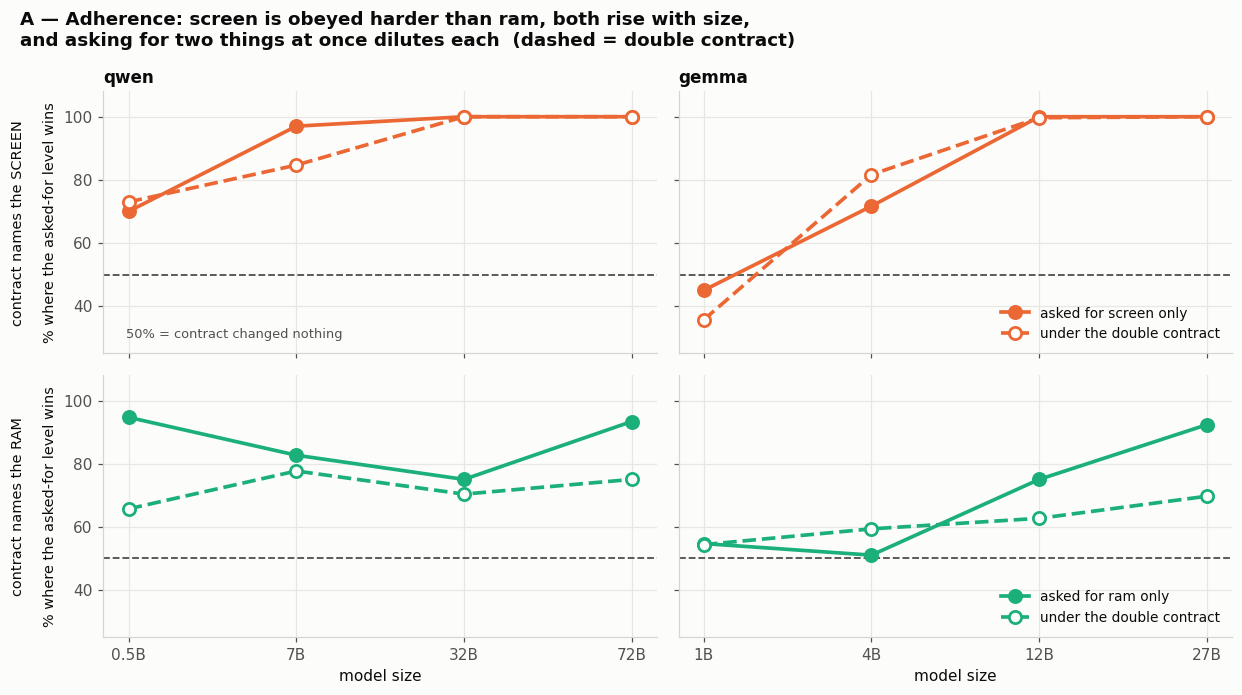

In [204]:
# --- Fig 5.5 A: small multiples. Rows = feature, columns = family. Two lines per panel. ---
fig, axes = plt.subplots(2, 2, figsize=(11.4, 6.4), sharex="col", sharey=True)
for r, feat in enumerate(["screen", "ram"]):
    single = "14in" if feat == "screen" else "8GB"
    for c, fam in enumerate(["qwen", "gemma"]):
        ax = axes[r, c]
        sizes = SIZES[fam]
        xs = range(len(sizes))
        for con, ls, mfc, lab in [(single, "-", FEAT_C[feat], f"asked for {feat} only"),
                                  ("14in+8GB", "--", SURFACE, "under the double contract")]:
            ax.plot(xs, [GOT[(lbl(fam, s), con, feat)] for s in sizes], ls + "o",
                    color=FEAT_C[feat], ms=8, lw=2.4, mfc=mfc, mew=1.8, label=lab, zorder=3)
        ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
        ax.set_ylim(25, 108)
        ax.set_xticks(list(xs), [f"{s}B" for s in sizes])
        if r == 0:
            ax.set_title(fam, loc="left", fontweight="bold", fontsize=11)
        if r == 1:
            ax.set_xlabel("model size")
        if c == 0:
            ax.set_ylabel(f"contract names the {feat.upper()}\n\n% where the asked-for "
                          f"level wins", fontsize=9.5)
axes[0, 0].text(.04, .06, "50% = contract changed nothing", transform=axes[0, 0].transAxes,
                fontsize=8.5, color=INK_MUTED)
for r, feat in enumerate(["screen", "ram"]):
    axes[r, 1].legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle("A — Adherence: screen is obeyed harder than ram, both rise with size,\n"
             "and asking for two things at once dilutes each  (dashed = double contract)",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_adherence_A_smallmultiples")
plt.show()

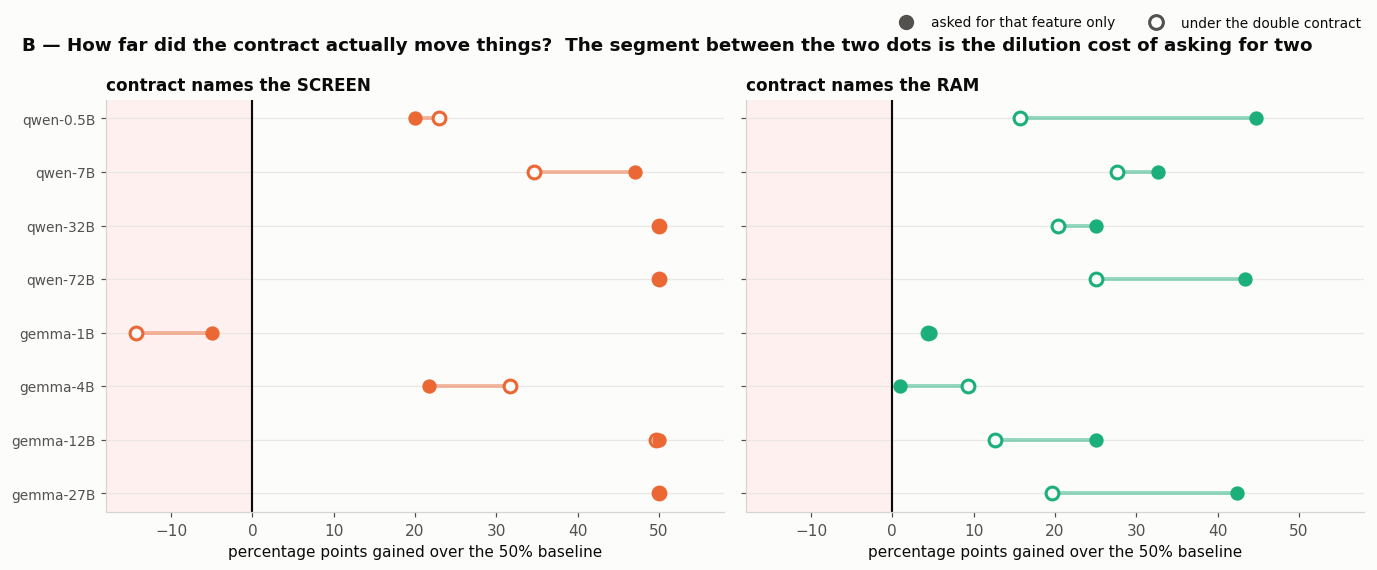

In [205]:
# --- Fig 5.5 B: lollipop. Encodes the GAIN over the 50% "did nothing" baseline. ---
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0), sharex=True, sharey=True)
order = [lbl(f, s) for f, s in ALL][::-1]          # biggest at the top
for ax, feat in zip(axes, ["screen", "ram"]):
    single = "14in" if feat == "screen" else "8GB"
    y = np.arange(len(order))
    a = np.array([GOT[(m, single, feat)] - 50 for m in order])
    b = np.array([GOT[(m, "14in+8GB", feat)] - 50 for m in order])
    ax.hlines(y, np.minimum(a, b), np.maximum(a, b), color=FEAT_C[feat], lw=2.6,
              alpha=.45, zorder=2)
    ax.scatter(b, y, s=70, facecolor=SURFACE, edgecolor=FEAT_C[feat], linewidth=2,
               zorder=4, label="under the double contract")
    ax.scatter(a, y, s=70, color=FEAT_C[feat], zorder=5, label=f"asked for {feat} only")
    ax.axvline(0, color=INK, lw=1.4)
    ax.set_yticks(y, order, fontsize=9)
    ax.set_xlim(-18, 58)
    ax.set_xlabel("percentage points gained over the 50% baseline")
    ax.set_title(f"contract names the {feat.upper()}", loc="left", fontweight="bold",
                 fontsize=11)
    ax.grid(axis="x")
    # no annotations near the axis: the black line at 0 plus the xlabel already say it
    ax.axvspan(-18, 0, color="#fdf0ef", zorder=0)      # the "it backfired" side
# one shared legend, in neutral ink: the two panels use different hues for the same idea
fig.legend(handles=[Line2D([], [], marker="o", ls="", ms=9, color=INK_MUTED),
                    Line2D([], [], marker="o", ls="", ms=9, mfc=SURFACE,
                           mec=INK_MUTED, mew=2)],
           labels=["asked for that feature only", "under the double contract"],
           loc="upper right", ncol=2, frameon=False, fontsize=9,
           bbox_to_anchor=(.995, 1.04))
fig.suptitle("B — How far did the contract actually move things?  "
             "The segment between the two dots is the dilution cost of asking for two",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_adherence_B_lollipop")
plt.show()

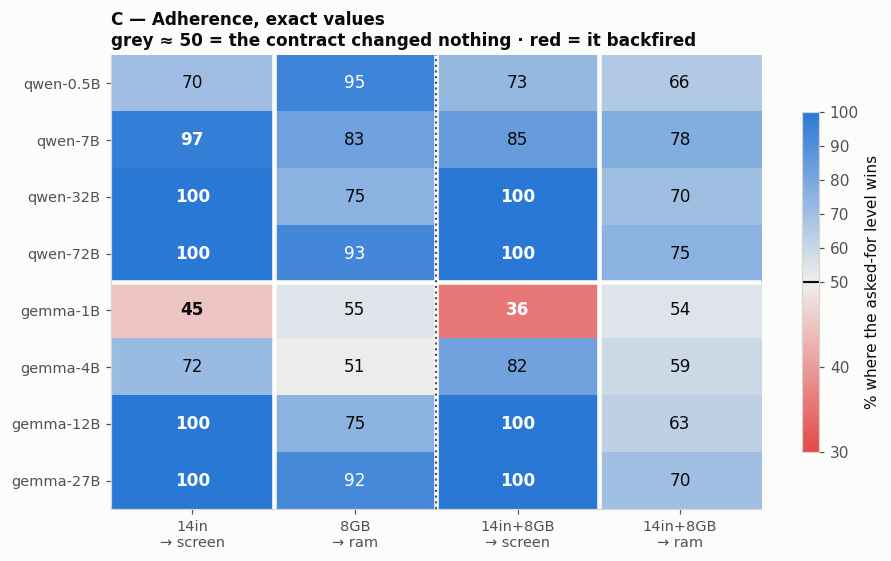

In [206]:
# --- Fig 5.5 C: numeric heatmap, diverging around the 50% "did nothing" point. ---
order = [lbl(f, s) for f, s in ALL]
M = np.array([[GOT[(m, con, feat)] for con, feat in SERIES] for m in order])

fig, ax = plt.subplots(figsize=(8.6, 5.2))
im = ax.imshow(M, cmap=DIVERGING, norm=TwoSlopeNorm(50, 30, 100), aspect="auto")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=11,
                fontweight="bold" if v >= 95 or v < 50 else "normal",
                color="#ffffff" if v > 88 or v < 40 else INK)
ax.set_xticks(range(4), [f"{c}\n→ {f}" for c, f in SERIES], fontsize=9.5)
ax.set_yticks(range(len(order)), order, fontsize=9.5)
ax.axhline(3.5, color=SURFACE, lw=3)                 # split the two families
for j in (0.5, 1.5, 2.5):
    ax.axvline(j, color=SURFACE, lw=3)
ax.axvline(1.5, color=INK_MUTED, lw=1.4, ls=":")     # single | double
# the column labels already name the contracts, so no group headers on top of the title
cb = fig.colorbar(im, ax=ax, shrink=.75)
cb.set_label("% where the asked-for level wins")
cb.ax.axhline(50, color=INK, lw=1.4)
ax.grid(False)
ax.set_title("C — Adherence, exact values\n"
             "grey ≈ 50 = the contract changed nothing · red = it backfired",
             loc="left", fontweight="bold", fontsize=11)
fig.tight_layout()
save(fig, "s05_adherence_C_heatmap")
plt.show()

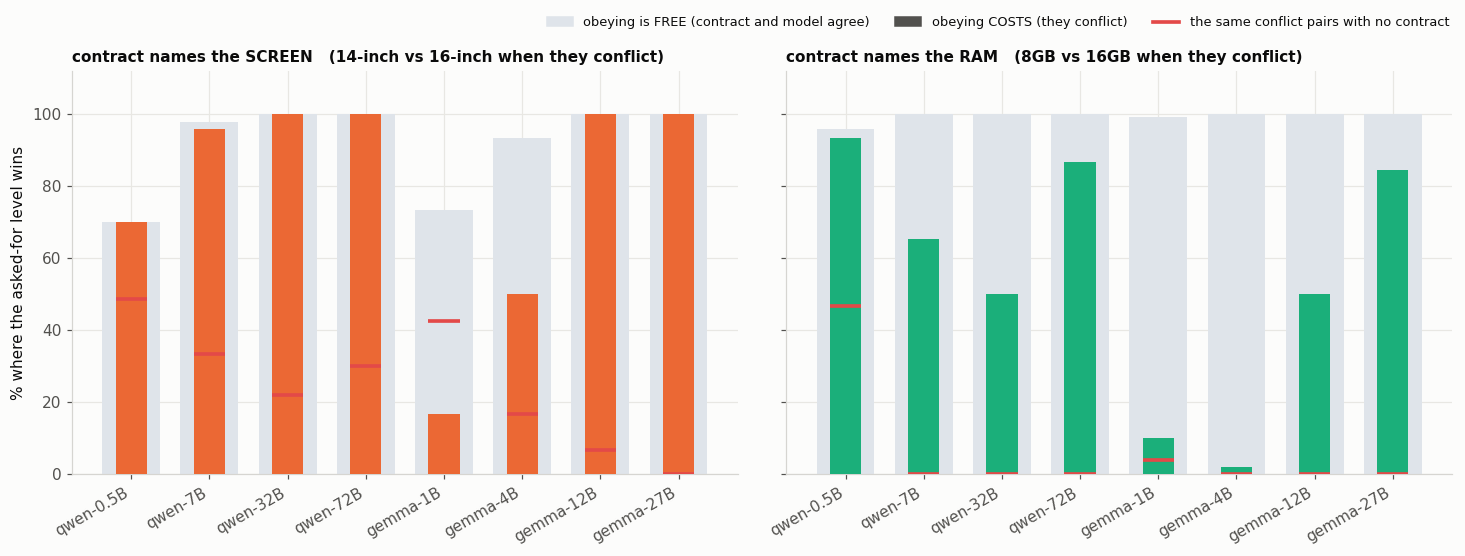

           agree        conflict       
feat         ram screen      ram screen
model                                  
qwen-0.5B   96.0   70.0     93.3   70.0
qwen-7B    100.0   98.0     65.3   96.0
qwen-32B   100.0  100.0     50.0  100.0
qwen-72B   100.0  100.0     86.7  100.0
gemma-1B    99.3   73.3     10.0   16.7
gemma-4B   100.0   93.3      2.0   50.0
gemma-12B  100.0  100.0     50.0  100.0
gemma-27B  100.0  100.0     84.7  100.0

mean over the 7 models with real signal:
        before  conflict  agree
feat                           
ram        0.6      49.8   99.9
screen    21.6      80.4   95.0

Every real model is at ~100 on the FREE column. The spread is entirely in the
COSTS column, so that is the only one worth putting a model-size story on.


In [236]:
# --- Fig 5.5 D: split adherence into the two directions the contract creates. ---
# Every contract makes two kinds of comparison, and averaging them (Fig 5.5 / A / B / C)
# hides the only informative one:
#   AGREE    the contract and the model's own order want the same laptop  (8GB vs 4GB)
#            -> obeying is free
#   CONFLICT they want different laptops                                  (8GB vs 16GB)
#            -> obeying means giving up a RAM step
# All ceteris paribus: brand and screen tied, so only the named feature differs. 150 rows
# per bar. The red tick is the same conflict pairs with NO contract - where the model started.
CONFLICT = {"screen": ("14-inch", "16-inch"), "ram": ("8GB", "16GB")}
AGREE    = {"screen": ("14-inch", "13-inch"), "ram": ("8GB", "4GB")}
ASKED    = {"screen": "14-inch", "ram": "8GB"}
RUN_OF   = {"screen": "screen=14-inch", "ram": "ram=8GB"}


def pair2(d, u, v, col):
    return (((d[f"a_{col}"] == u) & (d[f"b_{col}"] == v))
            | ((d[f"a_{col}"] == v) & (d[f"b_{col}"] == u))).values


rows = []
for fam, s in ALL:
    for feat in ("screen", "ram"):
        d1, d0 = RUNS[(fam, s, RUN_OF[feat])], RUNS[(fam, s, "none")]
        want1 = (d1[f"a_{feat}"] == ASKED[feat]).values
        want0 = (d0[f"a_{feat}"] == ASKED[feat]).values
        rows.append(dict(
            model=lbl(fam, s), feat=feat,
            agree=winrate(d1, only_one(d1, feat) & pair2(d1, *AGREE[feat], feat), want1),
            conflict=winrate(d1, only_one(d1, feat) & pair2(d1, *CONFLICT[feat], feat), want1),
            before=winrate(d0, only_one(d0, feat) & pair2(d0, *CONFLICT[feat], feat), want0)))
SPLIT = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), sharey=True)
for ax, feat in zip(axes, ["screen", "ram"]):
    t = SPLIT[SPLIT.feat == feat].set_index("model").reindex([lbl(f, s) for f, s in ALL])
    x = np.arange(len(t))
    ax.bar(x, t.agree, .74, color="#dfe4ea", zorder=2,
           label="obeying is FREE  (contract and model agree)")
    ax.bar(x, t.conflict, .40, color=FEAT_C[feat], zorder=3,
           label="obeying COSTS  (they conflict)")
    ax.hlines(t.before, x - .20, x + .20, color=VIOLATE, lw=2.4, zorder=5,
              label="same conflict pairs, no contract")
    ax.set_xticks(x, t.index, rotation=30, ha="right")
    ax.set_ylim(0, 112)
    ax.set_title(f"contract names the {feat.upper()}"
                 f"   ({ASKED[feat]} vs {CONFLICT[feat][1]} when they conflict)",
                 loc="left", fontweight="bold", fontsize=10)
    ax.grid(axis="y", zorder=0)
axes[0].set_ylabel("% where the asked-for level wins")
# the bars fill both panels, so the key goes above them
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#dfe4ea"),
                    Rectangle((0, 0), 1, 1, color=INK_MUTED),
                    Line2D([], [], color=VIOLATE, lw=2.4)],
           labels=["obeying is FREE (contract and model agree)",
                   "obeying COSTS (they conflict)",
                   "the same conflict pairs with no contract"],
           loc="upper right", ncol=3, frameon=False, fontsize=8.5,
           bbox_to_anchor=(.995, 1.055))
# fig.suptitle("D — Every model HEARS the contract. Only the big ones PAY for it.\n"
#              "grey = what it does when obeying is free · coloured = when obeying costs",
#              x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_adherence_D_split")
plt.show()

out = SPLIT.pivot(index="model", columns="feat", values=["agree", "conflict"])
print(out.reindex([lbl(f, s) for f, s in ALL]).round(1).to_string())
print("\nmean over the 7 models with real signal:")
r7 = SPLIT[SPLIT.model != "qwen-0.5B"].groupby("feat")[["before", "conflict", "agree"]].mean()
print(r7.round(1).to_string())
print("\nEvery real model is at ~100 on the FREE column. The spread is entirely in the\n"
      "COSTS column, so that is the only one worth putting a model-size story on.")

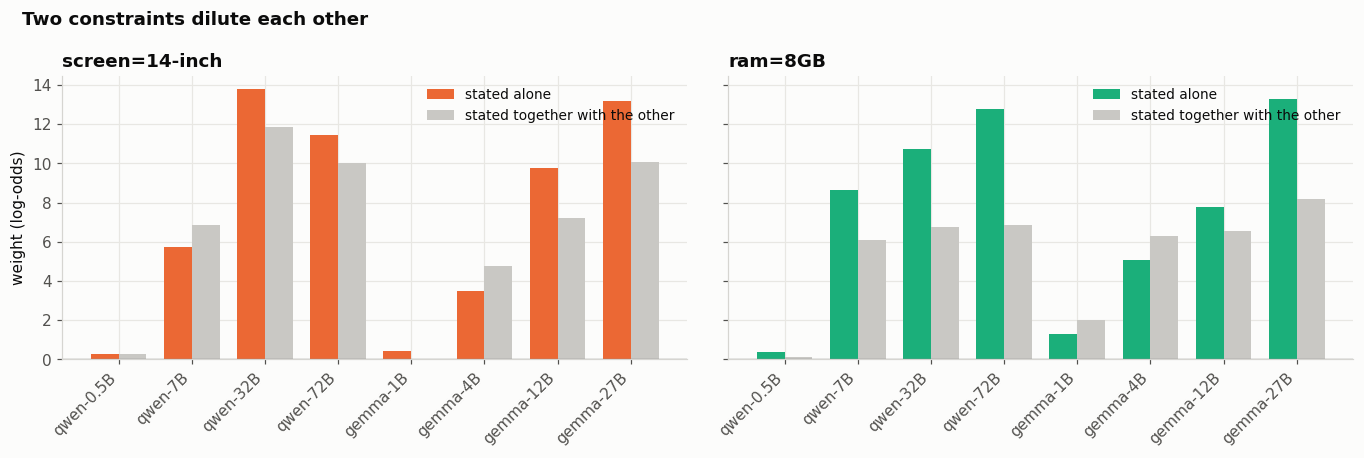

In [208]:
# Fig 5.2 - two constraints dilute each other.
rows = []
for fam, s in ALL:
    for con, (f, l) in SINGLE.items():
        rows.append(dict(model=lbl(fam, s), feat=f"{f}={l}",
                         alone=W[(fam, s, con)][f"{f}_{l}"],
                         together=W[(fam, s, "ram=8GB+screen=14-inch")][f"{f}_{l}"]))
D = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, f in zip(axes, D.feat.unique()):
    d = D[D.feat == f]
    x = np.arange(len(d))
    ax.bar(x - .19, d.alone, .38, color=FEATURE_COLOR["screen" if "screen" in f else "ram"],
           label="stated alone")
    ax.bar(x + .19, d.together, .38, color="#c9c8c4", label="stated together with the other")
    ax.set_xticks(x, d.model, rotation=45, ha="right")
    ax.set_title(f, loc="left", fontweight="bold")
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.legend(fontsize=9, frameon=False)
axes[0].set_ylabel("weight (log-odds)")
fig.suptitle("Two constraints dilute each other", x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s05_dilution")
plt.show()

---
# Slide 6 — The surprise

A contract that never mentions brand still reorders the brands.

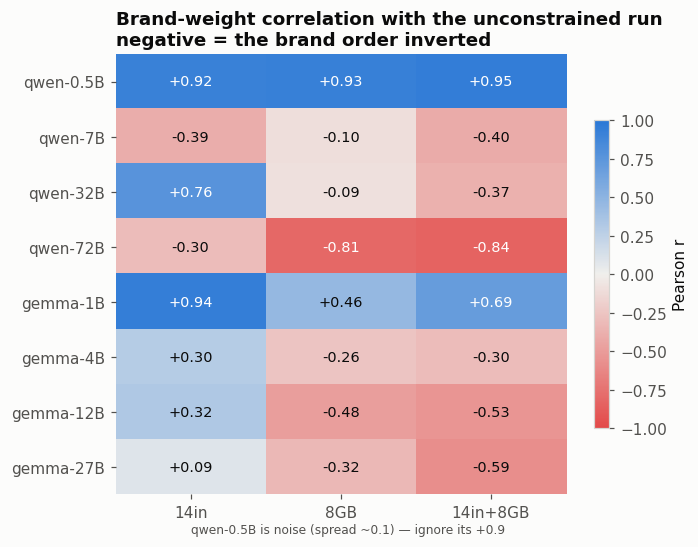

In [209]:
# Fig 6.1 - correlation of brand weights with the same model's unconstrained run.
Mc = np.array([[np.corrcoef(bvec(W[(f, s, "none")]), bvec(W[(f, s, c)]))[0, 1]
                for c in CON[1:]] for f, s in ALL])
fig, ax = plt.subplots(figsize=(6.6, 5.2))
im = ax.imshow(Mc, cmap=DIVERGING, norm=TwoSlopeNorm(0, -1, 1), aspect="auto")
for i in range(Mc.shape[0]):
    for j in range(Mc.shape[1]):
        ax.text(j, i, f"{Mc[i, j]:+.2f}", ha="center", va="center", fontsize=9.5,
                color=INK if abs(Mc[i, j]) < .6 else "white")
ax.set_xticks(range(3), cols[1:])
ax.set_yticks(range(len(ALL)), [lbl(f, s) for f, s in ALL])
ax.set_title("Brand-weight correlation with the unconstrained run\n"
             "negative = the brand order inverted", loc="left", fontweight="bold")
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
fig.colorbar(im, ax=ax, shrink=.7, label="Pearson r")
ax.text(0, len(ALL) + .2, "qwen-0.5B is noise (spread ~0.1) — ignore its +0.9",
        fontsize=8, color=INK_MUTED, transform=ax.transData)
save(fig, "s06_brand_corr")
plt.show()

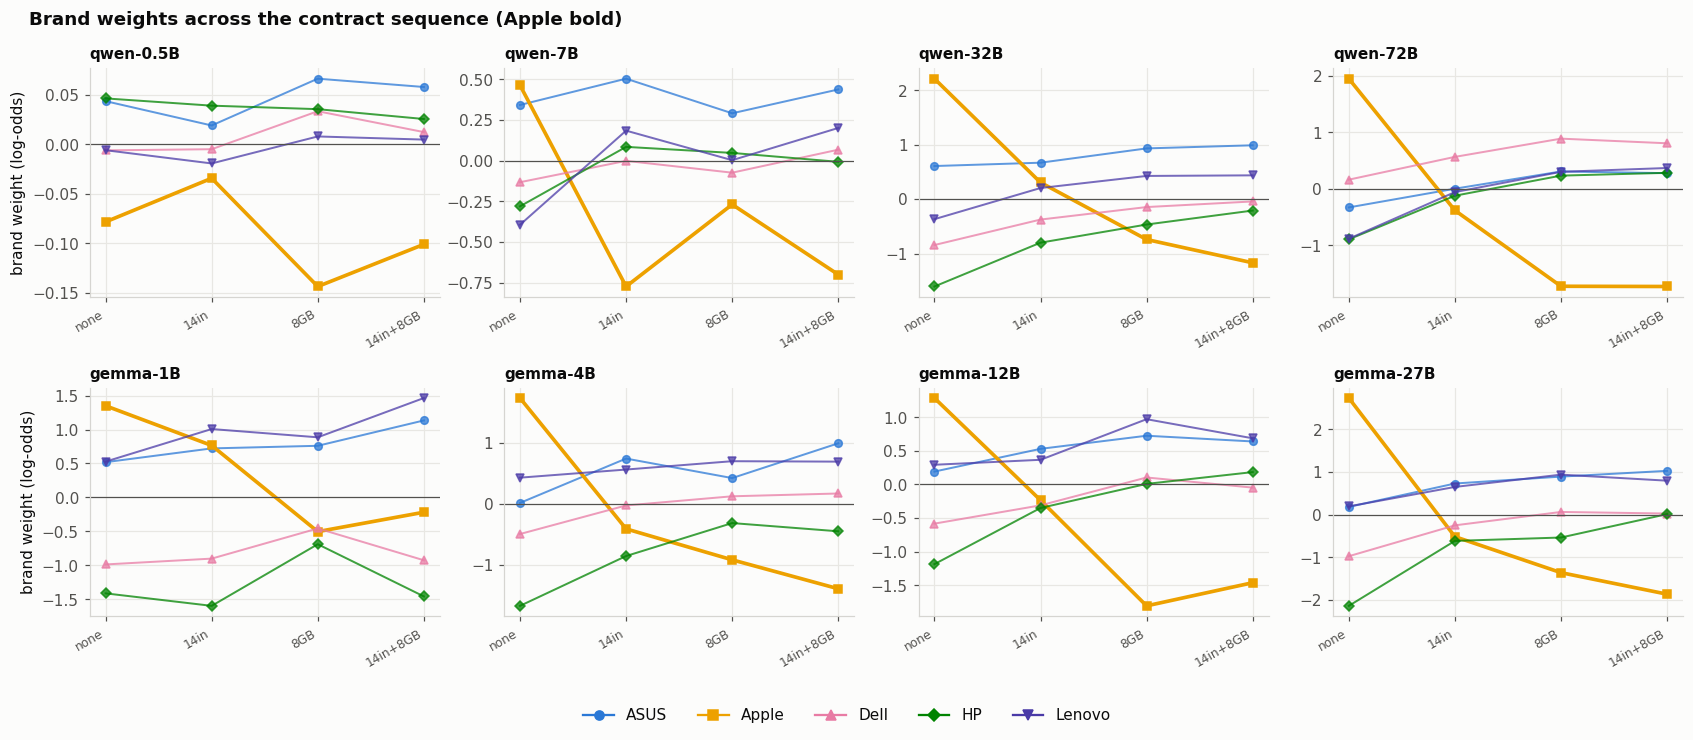

In [210]:
# Fig 6.2 - every brand's weight across the four phases, one panel per model.
fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.6))
for ax, (fam, s) in zip(axes.ravel(), ALL):
    for i, b in enumerate(BRANDS):
        y = [W[(fam, s, c)][f"brand_{b}"] for c in CON]
        ax.plot(range(4), y, "-", marker=BRAND_MARKER[b], color=BRAND_COLOR[b],
                ms=5, lw=2.4 if b == "Apple" else 1.3,
                alpha=1.0 if b == "Apple" else .75)
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=8)
    ax.set_title(lbl(fam, s), loc="left", fontweight="bold", fontsize=10)
axes[0, 0].set_ylabel("brand weight (log-odds)")
axes[1, 0].set_ylabel("brand weight (log-odds)")
fig.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b], label=b)
                    for b in BRANDS], ncol=5, loc="lower center", frameon=False,
           bbox_to_anchor=(.5, -.02))
fig.suptitle("Brand weights across the contract sequence (Apple bold)",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, .05, 1, 1])
save(fig, "s06_brand_trajectories")
plt.show()

---
# Slide 7 — Correction: it is one brand

Drop Apple and the other four brands are stable. This corrects
`brand_consistency.ipynb`'s headline.

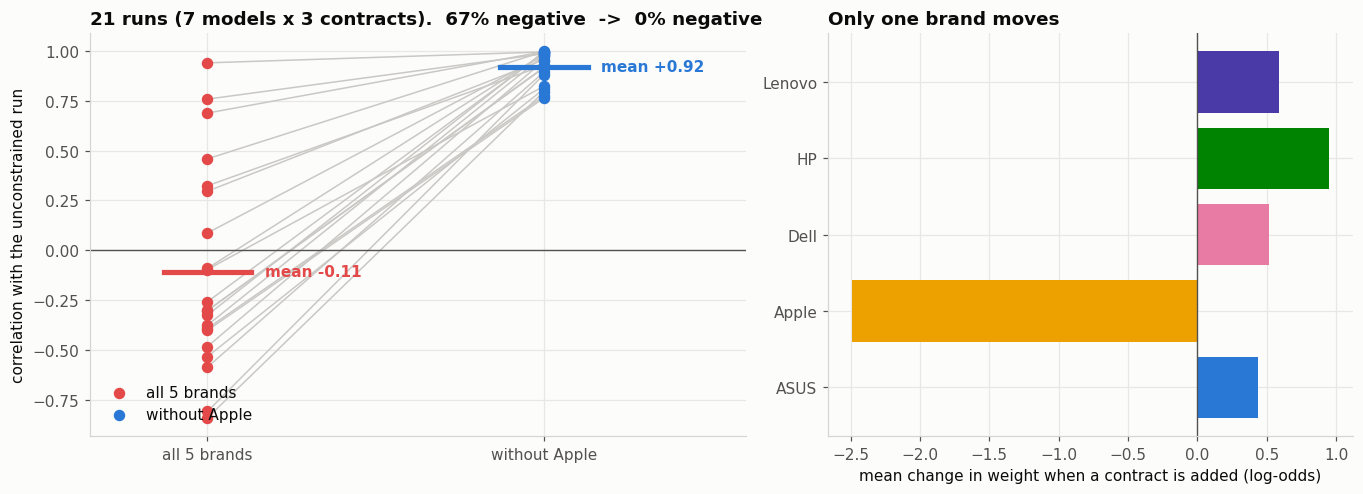

          all5  no_apple
con                     
14in      0.24      0.93
14in+8GB -0.34      0.88
8GB      -0.23      0.95

paired t-test all5 vs no_apple: TtestResult(statistic=np.float64(-10.116782373654258), pvalue=np.float64(2.6017132995636386e-09), df=np.int64(20))


In [211]:
# Fig 7.1 - all five brands vs the four that are not Apple, re-centred among themselves.
def corr_without_apple(w0, w1):
    a = np.array([w0[f"brand_{b}"] for b in OTHER])
    b_ = np.array([w1[f"brand_{b}"] for b in OTHER])
    return np.corrcoef(a - a.mean(), b_ - b_.mean())[0, 1]

rows = []
for fam, s in REAL:
    for c in CON[1:]:
        w0, w1 = W[(fam, s, "none")], W[(fam, s, c)]
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         all5=np.corrcoef(bvec(w0), bvec(w1))[0, 1],
                         no_apple=corr_without_apple(w0, w1)))
P = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6),
                         gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
for _, r in P.iterrows():
    ax.plot([0, 1], [r.all5, r.no_apple], "-", color="#c9c8c4", lw=1, zorder=1)
ax.scatter(np.zeros(len(P)), P.all5, s=42, color=VIOLATE, zorder=3, label="all 5 brands")
ax.scatter(np.ones(len(P)), P.no_apple, s=42, color=SATISFY, zorder=3, label="without Apple")
for x, v, c in [(0, P.all5.mean(), VIOLATE), (1, P.no_apple.mean(), SATISFY)]:
    ax.plot([x - .13, x + .13], [v, v], color=c, lw=3.4, zorder=4)
    ax.text(x + .17, v, f"mean {v:+.2f}", color=c, va="center", fontweight="bold")
ax.axhline(0, color=INK_MUTED, lw=.9)
ax.set_xlim(-.35, 1.6); ax.set_xticks([0, 1], ["all 5 brands", "without Apple"])
ax.set_ylabel("correlation with the unconstrained run")
ax.set_title(f"21 runs (7 models x 3 contracts).  "
             f"{100*(P.all5<0).mean():.0f}% negative  ->  {100*(P.no_apple<0).mean():.0f}% negative",
             loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower left")

ax = axes[1]
# "move" not "shift" - DataFrame.shift is a method, so Pb.shift would not be the column.
Pb = pd.DataFrame([
    dict(brand=b, move=np.mean([W[(f, s, c)][f"brand_{b}"] - W[(f, s, "none")][f"brand_{b}"]
                                for f, s in REAL for c in CON[1:]]))
    for b in BRANDS])
ax.barh(Pb.brand, Pb.move, color=[BRAND_COLOR[b] for b in Pb.brand])
ax.axvline(0, color=INK_MUTED, lw=.9)
ax.set_xlabel("mean change in weight when a contract is added (log-odds)")
ax.set_title("Only one brand moves", loc="left", fontweight="bold")
fig.tight_layout()
save(fig, "s07_one_brand")
plt.show()

print(P.groupby("con")[["all5", "no_apple"]].mean().round(2))
print("\npaired t-test all5 vs no_apple:", st.ttest_rel(P.all5, P.no_apple))

---
# Slide 8 — The fact needs no model

Apple's win rate against a **same-spec** rival — same screen, same ram, brand is the
only difference. No Bradley-Terry involved.

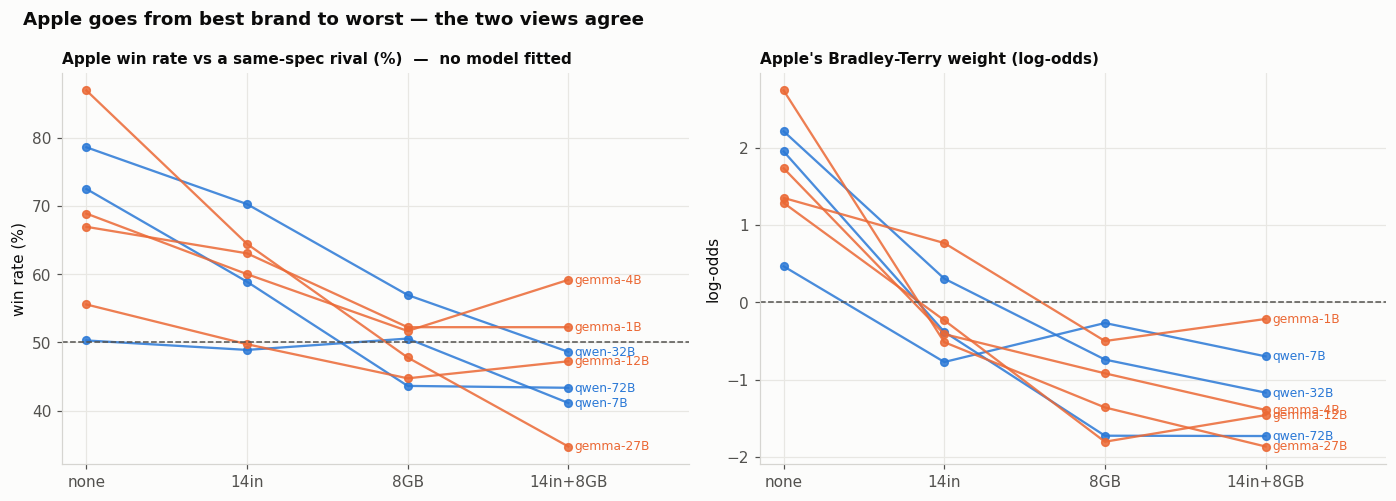

con        none  14in   8GB  14in+8GB
model                                
qwen-7B    50.3  48.9  50.6      41.1
qwen-32B   78.6  70.3  56.9      48.6
qwen-72B   72.5  58.9  43.6      43.3
gemma-1B   66.9  63.1  52.2      52.2
gemma-4B   68.9  60.0  51.7      59.2
gemma-12B  55.6  49.7  44.7      47.2
gemma-27B  86.9  64.4  47.8      34.7


In [212]:
# Fig 8.1 - raw win rate, and the fitted weight, side by side.
rows = []
for fam, s in REAL:
    for c in CON:
        d = RUNS[(fam, s, c)]
        d = d[(d.a_screen == d.b_screen) & (d.a_ram == d.b_ram)]
        m = (d.score_a - d.score_b).values
        mar = np.concatenate([m[(d.a_brand == "Apple").values],
                              -m[(d.b_brand == "Apple").values]])
        rows.append(dict(model=lbl(fam, s), fam=fam, con=CLAB[c],
                         win=100 * float((mar > 0).mean()),
                         w=W[(fam, s, c)]["brand_Apple"]))
A = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
for ax, (col, ttl, ref) in zip(axes, [
        ("win", "Apple win rate vs a same-spec rival (%)  —  no model fitted", 50),
        ("w", "Apple's Bradley-Terry weight (log-odds)", 0)]):
    for m in A.model.unique():
        d = A[A.model == m]
        fam = d.fam.iloc[0]
        ax.plot(range(4), d.set_index("con").reindex(cols)[col], "-o", ms=5,
                color=FAM_COLOR[fam], alpha=.85, label=m)
        ax.annotate(m, (3.04, d.set_index("con").reindex(cols)[col].iloc[-1]),
                    fontsize=8, va="center", color=FAM_COLOR[fam])
    ax.axhline(ref, color=INK_MUTED, lw=1, ls="--")
    ax.set_xticks(range(4), cols)
    ax.set_xlim(-.15, 3.75)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=10)
axes[0].set_ylabel("win rate (%)")
axes[1].set_ylabel("log-odds")
fig.suptitle("Apple goes from best brand to worst — the two views agree",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s08_modelfree")
plt.show()

print(A.pivot_table(index="model", columns="con", values="win").reindex(
    [lbl(f, s) for f, s in REAL])[cols].round(1))

---
# Slide 9 — Six conjectures, five rejected

The slide itself is the verdict table. These are the supporting panels — use one or
two, keep the rest as backup.

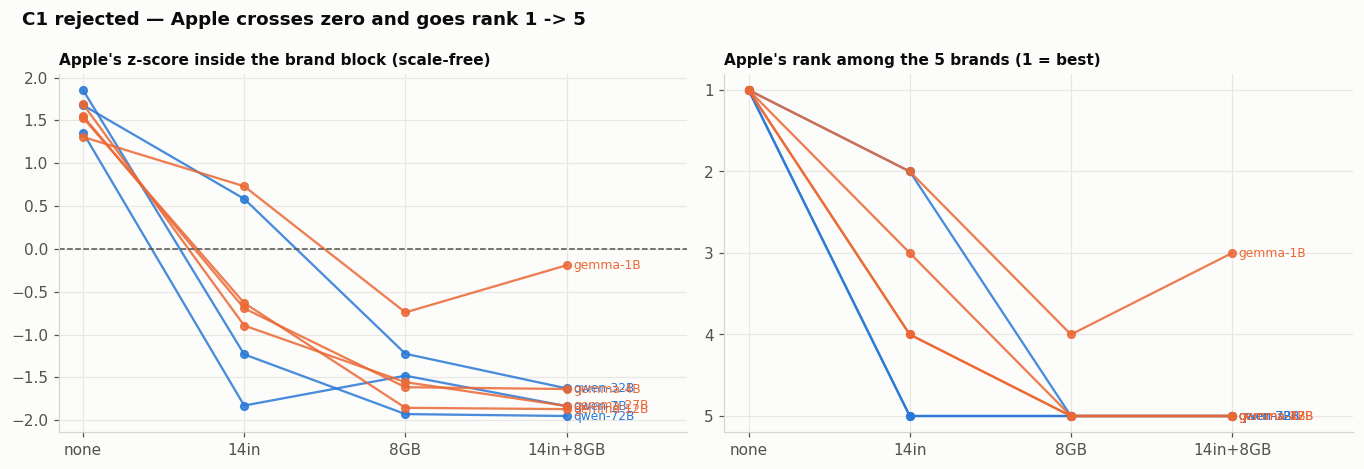

In [213]:
# Fig 9.1 (C1 - scale compression rejected): a rescale cannot change a rank.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, (col, ttl, ref) in zip(axes, [
        ("z", "Apple's z-score inside the brand block (scale-free)", 0),
        ("rank", "Apple's rank among the 5 brands (1 = best)", None)]):
    for fam, s in REAL:
        y = []
        for c in CON:
            bv = bvec(W[(fam, s, c)])
            y.append((bv[1] - bv.mean()) / bv.std(ddof=0) if col == "z"
                     else 1 + (bv > bv[1]).sum())
        ax.plot(range(4), y, "-o", ms=5, color=FAM_COLOR[fam], alpha=.85)
        ax.annotate(lbl(fam, s), (3.04, y[-1]), fontsize=8, va="center", color=FAM_COLOR[fam])
    if ref is not None:
        ax.axhline(ref, color=INK_MUTED, lw=1, ls="--")
    ax.set_xticks(range(4), cols); ax.set_xlim(-.15, 3.75)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=10)
axes[1].invert_yaxis()
axes[1].set_yticks([1, 2, 3, 4, 5])
fig.suptitle("C1 rejected — Apple crosses zero and goes rank 1 -> 5",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s09_c1_scale")
plt.show()

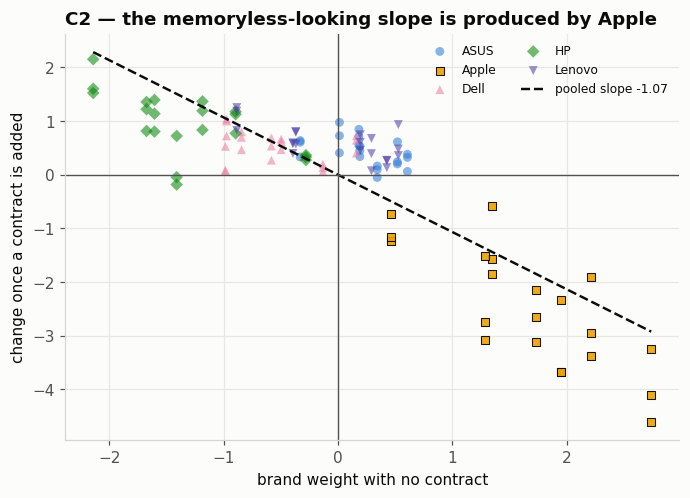

In [214]:
# Fig 9.2 (C2 - regression to the mean is not enough): Apple is an outlier from the line.
pts = []
for fam, s in REAL:
    for c in CON[1:]:
        w0, w1 = W[(fam, s, "none")], W[(fam, s, c)]
        for b in BRANDS:
            pts.append(dict(brand=b, base=w0[f"brand_{b}"],
                            delta=w1[f"brand_{b}"] - w0[f"brand_{b}"]))
G = pd.DataFrame(pts)
sl, ic, r, p, _ = st.linregress(G.base, G.delta)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for b in BRANDS:
    d = G[G.brand == b]
    ax.scatter(d.base, d.delta, s=34, color=BRAND_COLOR[b], marker=BRAND_MARKER[b],
               alpha=.9 if b == "Apple" else .55,
               edgecolor="black" if b == "Apple" else "none",
               linewidth=.7 if b == "Apple" else 0, label=b, zorder=3 if b == "Apple" else 2)
xs = np.linspace(G.base.min(), G.base.max(), 50)
ax.plot(xs, ic + sl * xs, color=INK, lw=1.6, ls="--",
        label=f"pooled slope {sl:.2f}")
ax.axhline(0, color=INK_MUTED, lw=.9); ax.axvline(0, color=INK_MUTED, lw=.9)
ax.set_xlabel("brand weight with no contract")
ax.set_ylabel("change once a contract is added")
ax.set_title("C2 — the memoryless-looking slope is produced by Apple",
             loc="left", fontweight="bold")
ax.legend(fontsize=8, frameon=False, ncol=2)
save(fig, "s09_c2_rtm")
plt.show()

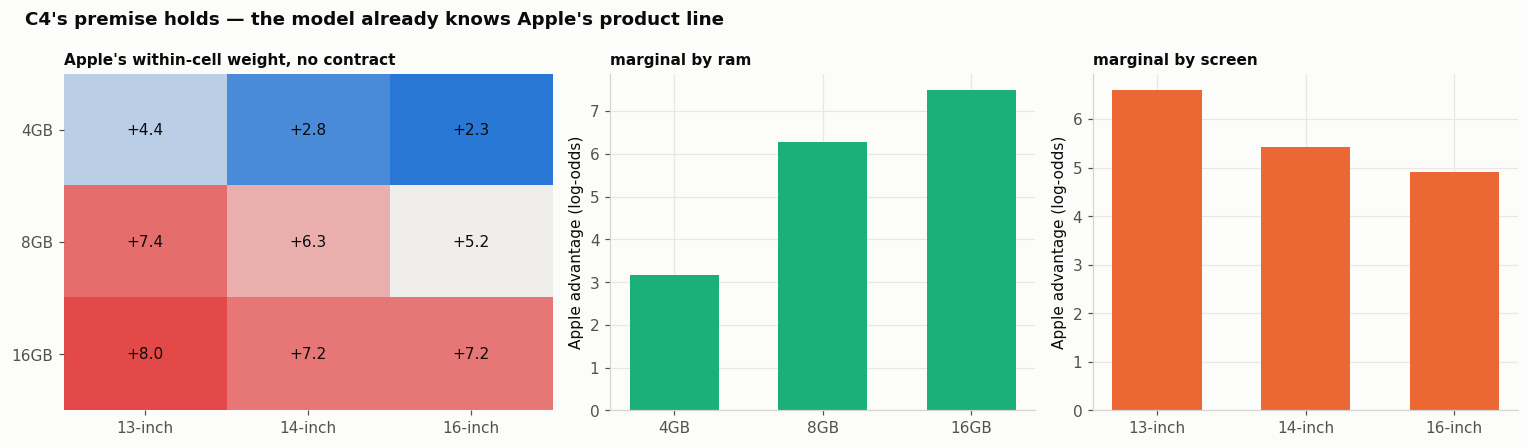

In [215]:
# Fig 9.3 (C4 premise is TRUE): Apple's advantage depends on the spec, before any contract.
u = E[E.con == "none"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1),
                         gridspec_kw={"width_ratios": [1.15, 1, 1]})
ax = axes[0]
piv = u.pivot_table(index="ram", columns="screen", values="apple").reindex(RM)[SC]
im = ax.imshow(piv.values, cmap=DIVERGING.reversed(), aspect="auto")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{piv.values[i, j]:+.1f}", ha="center", va="center", fontsize=10)
ax.set_xticks(range(3), SC); ax.set_yticks(range(3), RM)
ax.set_title("Apple's within-cell weight, no contract", loc="left", fontweight="bold", fontsize=10)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)

for ax, key, order in [(axes[1], "ram", RM), (axes[2], "screen", SC)]:
    m = u.groupby(key)["apple"].mean().reindex(order)
    ax.bar(range(3), m.values, color=FEATURE_COLOR[key], width=.6)
    ax.set_xticks(range(3), order)
    ax.set_title(f"marginal by {key}", loc="left", fontweight="bold", fontsize=10)
    ax.set_ylabel("Apple advantage (log-odds)")
fig.suptitle("C4's premise holds — the model already knows Apple's product line",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s09_c4_premise")
plt.show()

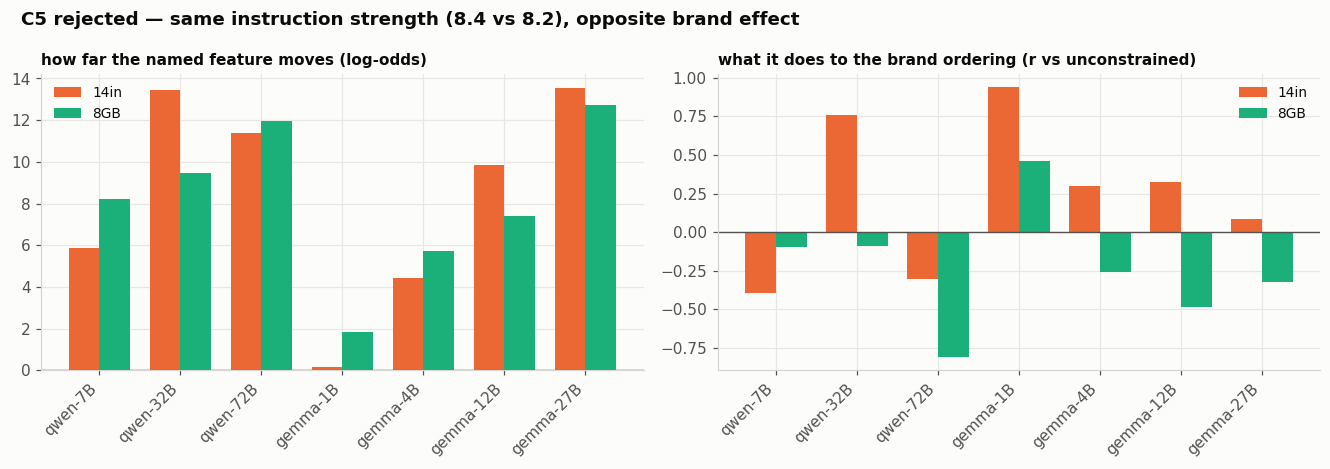

      move  brand_corr
con                   
14in  8.39        0.24
8GB   8.19       -0.23
paired t-test on brand_corr: TtestResult(statistic=np.float64(3.319867663374307), pvalue=np.float64(0.016006995871830864), df=np.int64(6))


In [216]:
# Fig 9.4 (C5 rejected): equal instruction strength, opposite effect on brand.
rows = []
for fam, s in REAL:
    w0 = W[(fam, s, "none")]
    for c in ("screen=14-inch", "ram=8GB"):
        (f, l), = CONSTRAINTS[(fam, s, c)].items()
        w1 = W[(fam, s, c)]
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         move=w1[f"{f}_{l}"] - w0[f"{f}_{l}"],
                         brand_corr=np.corrcoef(bvec(w0), bvec(w1))[0, 1]))
Dd = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3))
for ax, (col, ttl) in zip(axes, [
        ("move", "how far the named feature moves (log-odds)"),
        ("brand_corr", "what it does to the brand ordering (r vs unconstrained)")]):
    piv = Dd.pivot(index="model", columns="con", values=col).reindex(
        [lbl(f, s) for f, s in REAL])
    x = np.arange(len(piv))
    ax.bar(x - .19, piv["14in"], .38, color=FEATURE_COLOR["screen"], label="14in")
    ax.bar(x + .19, piv["8GB"], .38, color=FEATURE_COLOR["ram"], label="8GB")
    ax.set_xticks(x, piv.index, rotation=45, ha="right")
    ax.axhline(0, color=INK_MUTED, lw=.9)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=10)
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("C5 rejected — same instruction strength (8.4 vs 8.2), opposite brand effect",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s09_c5_content")
plt.show()
print(Dd.groupby("con")[["move", "brand_corr"]].mean().round(2))
print("paired t-test on brand_corr:", st.ttest_rel(
    Dd[Dd.con == "14in"].brand_corr.values, Dd[Dd.con == "8GB"].brand_corr.values))

---
# Slide 10 — The mechanism (C6)

Hold the spec cell completely fixed — 5 laptops that differ only in brand — and split
by whether that cell **satisfies** or **violates** the stated contract.

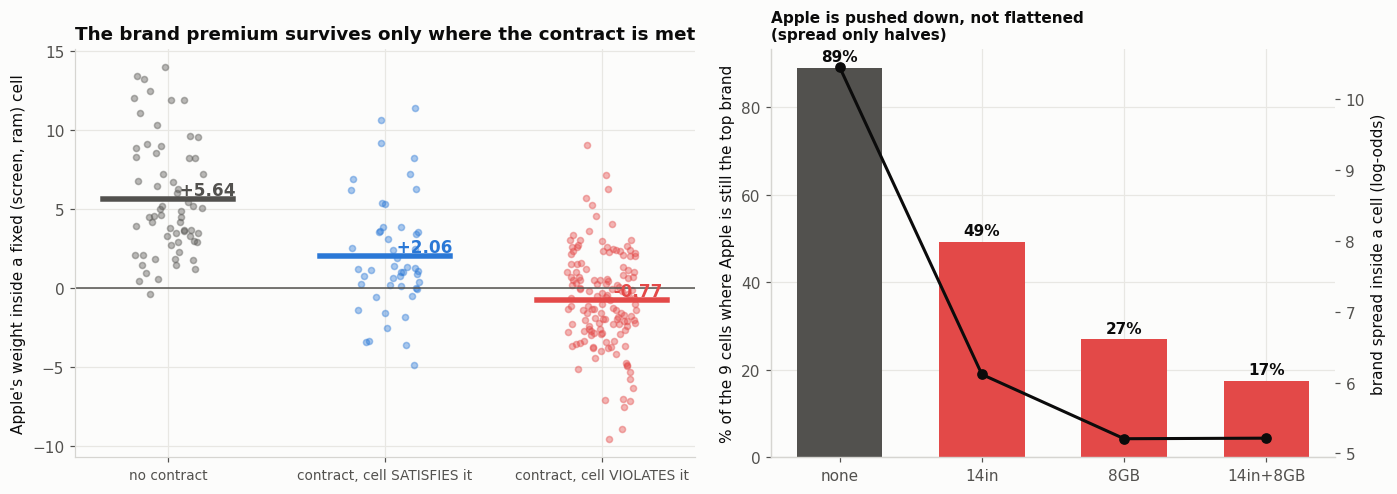

      apple           z       spread      
       mean count  mean count   mean count
sat                                       
False -0.77   140 -0.49   140   4.92   140
True   2.06    49  0.52    49   7.21    49
Welch t-test on Apple's z, satisfying vs violating: TtestResult(statistic=np.float64(5.143430706791791), pvalue=np.float64(1.273303391698093e-06), df=np.float64(104.15531605728262))


In [217]:
# Fig 10.1 - the headline panel of the whole deck.
sub = E[E.con != "none"].copy()
sub["sat"] = sub["sat"].astype(bool)
groups = [("no contract", E[E.con == "none"].apple.values, GAMMA_C),
          ("contract, cell SATISFIES it", sub[sub.sat].apple.values, SATISFY),
          ("contract, cell VIOLATES it", sub[~sub.sat].apple.values, VIOLATE)]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6),
                         gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
rng = np.random.default_rng(0)
for i, (name, v, c) in enumerate(groups):
    ax.scatter(i + rng.uniform(-.16, .16, len(v)), v, s=16, color=c, alpha=.4, zorder=2)
    ax.plot([i - .3, i + .3], [v.mean()] * 2, color=c, lw=3.6, zorder=4)
    ax.text(i, v.mean(), f"  {v.mean():+.2f}", color=c, fontweight="bold",
            va="bottom", ha="left", fontsize=11, zorder=5)
ax.axhline(0, color=INK_MUTED, lw=1)
ax.set_xticks(range(3), [g[0] for g in groups], fontsize=9)
ax.set_ylabel("Apple's weight inside a fixed (screen, ram) cell")
ax.set_title("The brand premium survives only where the contract is met",
             loc="left", fontweight="bold")

ax = axes[1]
top = E.groupby("con")["rank"].apply(lambda v: 100 * (v == 1).mean()).reindex(cols)
spr = E.groupby("con")["spread"].mean().reindex(cols)
ax.bar(range(4), top.values, color=[GAMMA_C] + [VIOLATE] * 3, width=.6)
for i, v in enumerate(top.values):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_xticks(range(4), cols)
ax.set_ylabel("% of the 9 cells where Apple is still the top brand")
ax2 = ax.twinx()
ax2.plot(range(4), spr.values, "-o", color=INK, lw=2)
ax2.set_ylabel("brand spread inside a cell (log-odds)")
ax2.grid(False)
ax.set_title("Apple is pushed down, not flattened\n(spread only halves)",
             loc="left", fontweight="bold", fontsize=10)
fig.tight_layout()
save(fig, "s10_c6_headline")
plt.show()

print(sub.groupby("sat")[["apple", "z", "spread"]].agg(["mean", "count"]).round(2))
print("Welch t-test on Apple's z, satisfying vs violating:",
      st.ttest_ind(sub[sub.sat].z.values, sub[~sub.sat].z.values, equal_var=False))

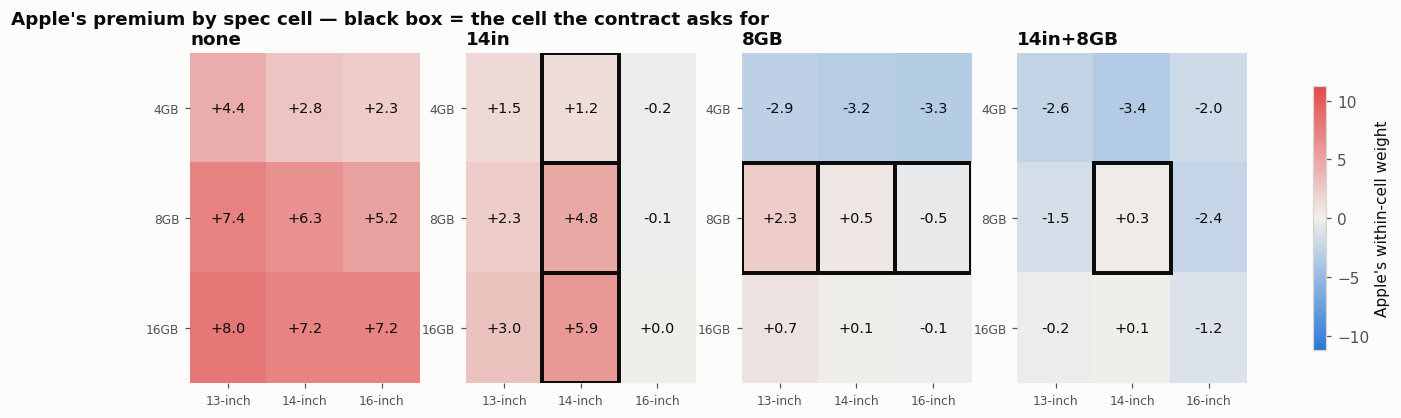

In [218]:
# Fig 10.2 - the 3x3 spec grid per contract. The contract cell is outlined.
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))
vmax = float(np.abs(E.apple).quantile(.97))
for ax, c in zip(axes, CON):
    d = E[E.con == CLAB[c]]
    piv = d.pivot_table(index="ram", columns="screen", values="apple").reindex(RM)[SC]
    im = ax.imshow(piv.values, cmap=DIVERGING.reversed(),
                   norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{piv.values[i, j]:+.1f}", ha="center", va="center", fontsize=9.5)
    con = CONSTRAINTS[("qwen", "32", c)]
    for i, rm in enumerate(RM):
        for j, sc in enumerate(SC):
            if con and satisfies(con, screen=sc, ram=rm):
                ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       edgecolor=INK, lw=2.6))
    ax.set_xticks(range(3), SC, fontsize=8); ax.set_yticks(range(3), RM, fontsize=8)
    ax.set_title(CLAB[c], loc="left", fontweight="bold")
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.colorbar(im, ax=axes, shrink=.8, label="Apple's within-cell weight")
fig.suptitle("Apple's premium by spec cell — black box = the cell the contract asks for",
             x=.02, ha="left", fontweight="bold")
save(fig, "s10_c6_grid")
plt.show()

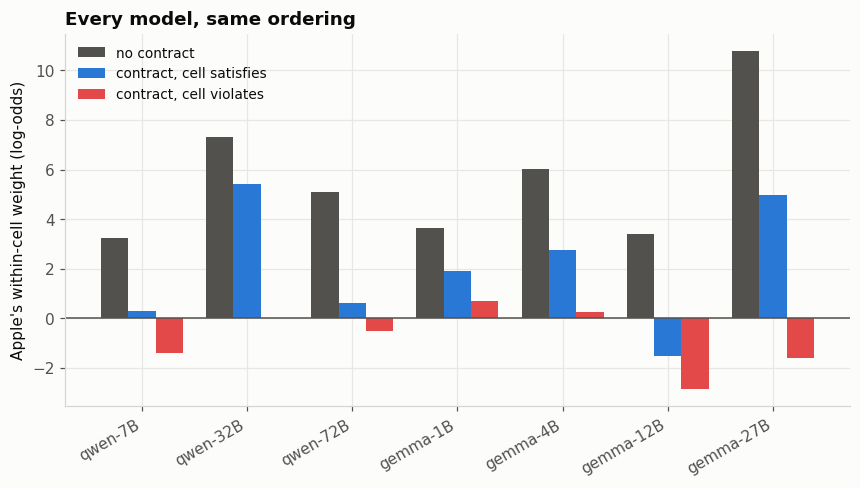

In [219]:
# Fig 10.3 - the same split, per model, so it is not an average hiding disagreement.
piv = sub.pivot_table(index="model", columns="sat", values="apple").reindex(
    [lbl(f, s) for f, s in REAL])
base = E[E.con == "none"].groupby("model")["apple"].mean().reindex(piv.index)
x = np.arange(len(piv))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x - .26, base, .26, color=GAMMA_C, label="no contract")
ax.bar(x, piv[True], .26, color=SATISFY, label="contract, cell satisfies")
ax.bar(x + .26, piv[False], .26, color=VIOLATE, label="contract, cell violates")
ax.axhline(0, color=INK_MUTED, lw=1)
ax.set_xticks(x, piv.index, rotation=30, ha="right")
ax.set_ylabel("Apple's within-cell weight (log-odds)")
ax.set_title("Every model, same ordering", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
save(fig, "s10_c6_permodel")
plt.show()

### Fig 10.4 — the ordinal version of the same split, one panel per phase

The weights above are log-odds, and the scale note says magnitudes are not trustworthy
while **rankings are**. So redo Fig 10.3 with ranks only.

A **cell** is 5 laptops with the same screen and ram, differing only in brand — 9 cells per
run. Each dot is the mean of Apple's rank over those cells. The phases are split because
they contribute very unequal numbers of cells:

| phase | cells that satisfy | cells that violate |
|---|---|---|
| `14in` | 3 (14-inch x 3 rams) | 6 |
| `8GB` | 3 (3 screens x 8GB) | 6 |
| `14in+8GB` | **1** (only 14-inch/8GB) | 8 |

Pooling them, as the earlier version did, lets `14in` and `8GB` dominate the "satisfies"
number while `14in+8GB` contributes a single cell.

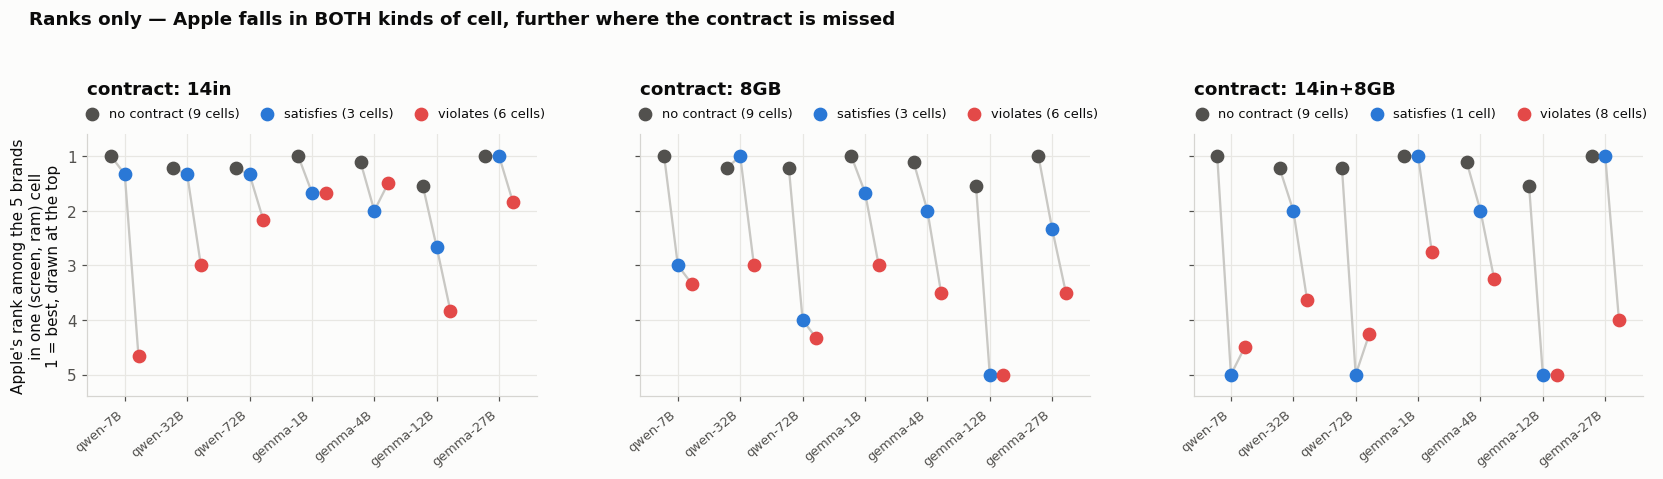

Apple's mean rank within a cell (1 = best of 5 brands), by phase:
                    mean  count
con      grp                   
14in     satisfies  1.62     21
         violates   2.67     42
14in+8GB satisfies  3.00      7
         violates   3.91     56
8GB      satisfies  2.71     21
         violates   3.67     42
none     none       1.16     63

% of cells where Apple is still rank 1:
con       grp      
14in      satisfies    67.0
          violates     40.0
14in+8GB  satisfies    29.0
          violates     16.0
8GB       satisfies    38.0
          violates     21.0
none      none         89.0
Name: rank, dtype: float64


In [220]:
# Fig 10.4 - Apple's rank inside a fixed (screen, ram) cell. One panel per phase.
E2 = E.copy()
E2["grp"] = np.where(E2.con == "none", "none",
                     np.where(E2.sat.fillna(False).astype(bool), "satisfies", "violates"))
MODELS = [lbl(f, s) for f, s in REAL]
none_rank = E2[E2.grp == "none"].groupby("model")["rank"].mean().reindex(MODELS)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharey=True)
x = np.arange(len(MODELS))
for ax, c in zip(axes, cols[1:]):
    d = E2[E2.con == c]
    sat_r = d[d.grp == "satisfies"].groupby("model")["rank"].mean().reindex(MODELS)
    vio_r = d[d.grp == "violates"].groupby("model")["rank"].mean().reindex(MODELS)
    n_sat = int((d.grp == "satisfies").sum() / len(MODELS))
    n_vio = int((d.grp == "violates").sum() / len(MODELS))
    for xi in x:
        ax.plot([xi - .22, xi, xi + .22],
                [none_rank.iloc[xi], sat_r.iloc[xi], vio_r.iloc[xi]],
                "-", color="#c9c8c4", lw=1.5, zorder=1)
    def plural(n):
        return f"{n} cell" if n == 1 else f"{n} cells"
    ax.scatter(x - .22, none_rank, s=64, color=GAMMA_C, zorder=3, label="no contract (9 cells)")
    ax.scatter(x, sat_r, s=64, color=SATISFY, zorder=3, label=f"satisfies ({plural(n_sat)})")
    ax.scatter(x + .22, vio_r, s=64, color=VIOLATE, zorder=3, label=f"violates ({plural(n_vio)})")
    ax.set_xticks(x, MODELS, rotation=40, ha="right", fontsize=8.5)
    ax.set_xlim(-.6, len(MODELS) - .4)
    # cell counts differ per phase, so each panel needs its own legend - put it above the
    # axes, where no data can sit.
    ax.legend(frameon=False, fontsize=8.5, ncol=3, loc="lower center",
              bbox_to_anchor=(.5, 1.01), handletextpad=.3, columnspacing=1.1)
    ax.set_title(f"contract: {c}", loc="left", fontweight="bold", pad=26)
axes[0].set_ylim(5.4, 0.6)
axes[0].set_yticks([1, 2, 3, 4, 5])
axes[0].set_ylabel("Apple's rank among the 5 brands\nin one (screen, ram) cell\n"
                   "1 = best, drawn at the top")
fig.suptitle("Ranks only — Apple falls in BOTH kinds of cell, further where the contract is missed",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .94])
save(fig, "s10_c6_ordinal_cells")
plt.show()

print("Apple's mean rank within a cell (1 = best of 5 brands), by phase:")
print(E2.groupby(["con", "grp"])["rank"].agg(["mean", "count"]).round(2))
print("\n% of cells where Apple is still rank 1:")
print(E2.groupby(["con", "grp"])["rank"].apply(lambda v: 100 * (v == 1).mean()).round(0))

### Fig 10.5 — the sharper question

Throw away every laptop that does **not** satisfy the contract. Among the ones that are
left, where does the best Apple sit? Non-compliant Apples cannot contribute at all here,
so this asks whether the premium survives *where the contract is met*.

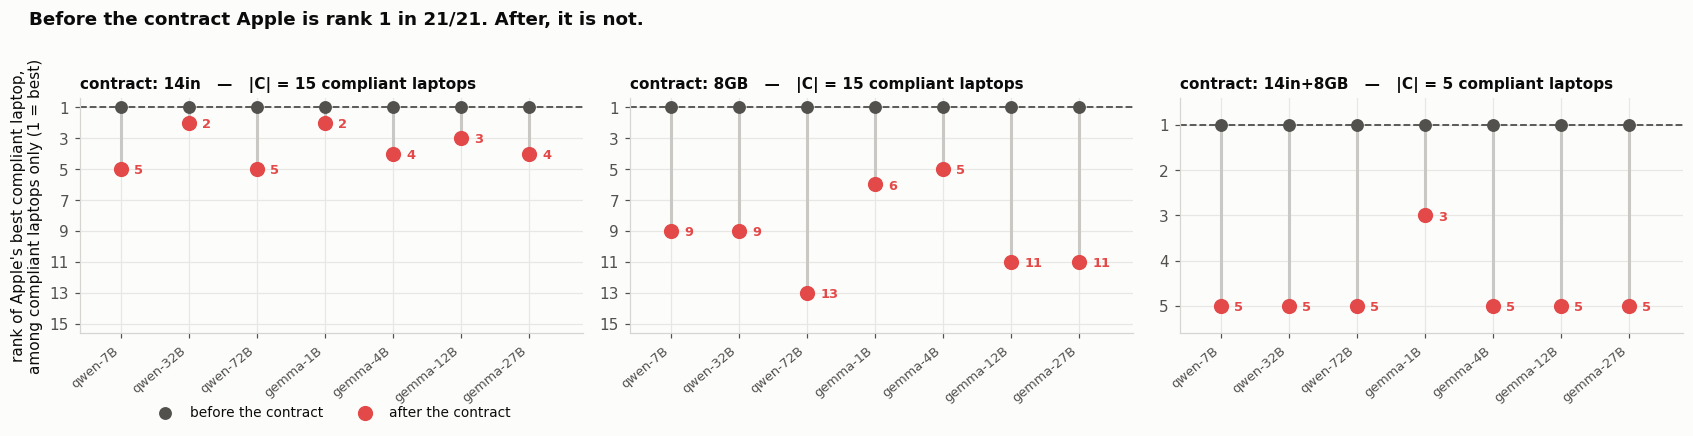

Rank of Apple's best compliant laptop inside C (before is 1 everywhere):
con        14in   8GB  14in+8GB
model                          
qwen-7B     5.0   9.0       5.0
qwen-32B    2.0   9.0       5.0
qwen-72B    5.0  13.0       5.0
gemma-1B    2.0   6.0       3.0
gemma-4B    4.0   5.0       5.0
gemma-12B   3.0  11.0       5.0
gemma-27B   4.0  11.0       5.0

mean after, by contract: {'14in': 3.57, '14in+8GB': 4.71, '8GB': 9.14}


In [221]:
# Fig 10.5 - rank of Apple's best COMPLIANT laptop, inside the feasible set C.
rows = []
for fam, s in REAL:
    for c in CON[1:]:
        con = CONSTRAINTS[(fam, s, c)]
        S = [k for k in item_utils(W[(fam, s, c)])
             if satisfies(con, screen=k[1], ram=k[2])]
        r = {}
        for tag, key in [("before", (fam, s, "none")), ("after", (fam, s, c))]:
            u = item_utils(W[key])
            ranked = sorted(S, key=u.get, reverse=True)
            r[tag] = 1 + next(i for i, k in enumerate(ranked) if k[0] == "Apple")
        rows.append(dict(model=lbl(fam, s), con=CLAB[c], n=len(S), **r))
CMP = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
for ax, c in zip(axes, cols[1:]):
    d = CMP[CMP.con == c].set_index("model").reindex(MODELS)
    nC = int(d.n.iloc[0])
    for xi, m in enumerate(MODELS):
        ax.plot([xi, xi], [d.loc[m, "before"], d.loc[m, "after"]],
                color="#c9c8c4", lw=2, zorder=1)
        ax.scatter([xi], [d.loc[m, "before"]], s=55, color=GAMMA_C, zorder=3)
        ax.scatter([xi], [d.loc[m, "after"]], s=80, color=VIOLATE, zorder=3)
        ax.annotate(f"{int(d.loc[m, 'after'])}", (xi, d.loc[m, "after"]),
                    textcoords="offset points", xytext=(9, -3), fontsize=8.5,
                    color=VIOLATE, fontweight="bold")
    ax.axhline(1, color=GAMMA_C, lw=1.2, ls="--")
    ax.set_ylim(nC + .6, .4)
    ax.set_yticks(range(1, nC + 1, 1 if nC <= 5 else 2))
    ax.set_xticks(range(len(MODELS)), MODELS, rotation=40, ha="right", fontsize=8.5)
    ax.set_xlim(-.6, len(MODELS) - .2)
    ax.set_title(f"contract: {c}   —   |C| = {nC} compliant laptops",
                 loc="left", fontweight="bold", fontsize=10)
axes[0].set_ylabel("rank of Apple's best compliant laptop,\n"
                   "among compliant laptops only (1 = best)")
axes[0].scatter([], [], s=55, color=GAMMA_C, label="before the contract")
axes[0].scatter([], [], s=80, color=VIOLATE, label="after the contract")
axes[0].legend(frameon=False, fontsize=9, loc="lower center", bbox_to_anchor=(.5, -.42), ncol=2)
fig.suptitle("Before the contract Apple is rank 1 in 21/21. After, it is not.",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .95])
save(fig, "s10_c6_ordinal_feasible")
plt.show()

print("Rank of Apple's best compliant laptop inside C (before is 1 everywhere):")
print(CMP.pivot_table(index="model", columns="con", values="after").reindex(MODELS)[
    cols[1:]].to_string())
print("\nmean after, by contract:", CMP.groupby("con")["after"].mean().round(2).to_dict())

# Slide 10b — Why: it is a priority list, not a utility

Everything up to here fitted an **additive** utility, `u = brand + screen + ram`, which
assumes the features **trade off**. They do not. The models walk down a priority order:
**RAM decides; if RAM ties, screen mostly decides; brand only speaks when both are tied.**

Terms used on these slides (full walkthrough in `explainer_lexicographic.ipynb`):

- **veto** (standard term: *non-compensatory* / lexicographic in that feature) — whenever the
  feature differs it decides, whatever else differs. Measured: 100%.
- **tendency** (*compensatory*) — usually decides, can be outvoted. Measured: 50-100%.
- **tie-breaker** — only speaks once the features above it are tied.

This is what explains the ram-vs-screen asymmetry on slides 9 and 10.

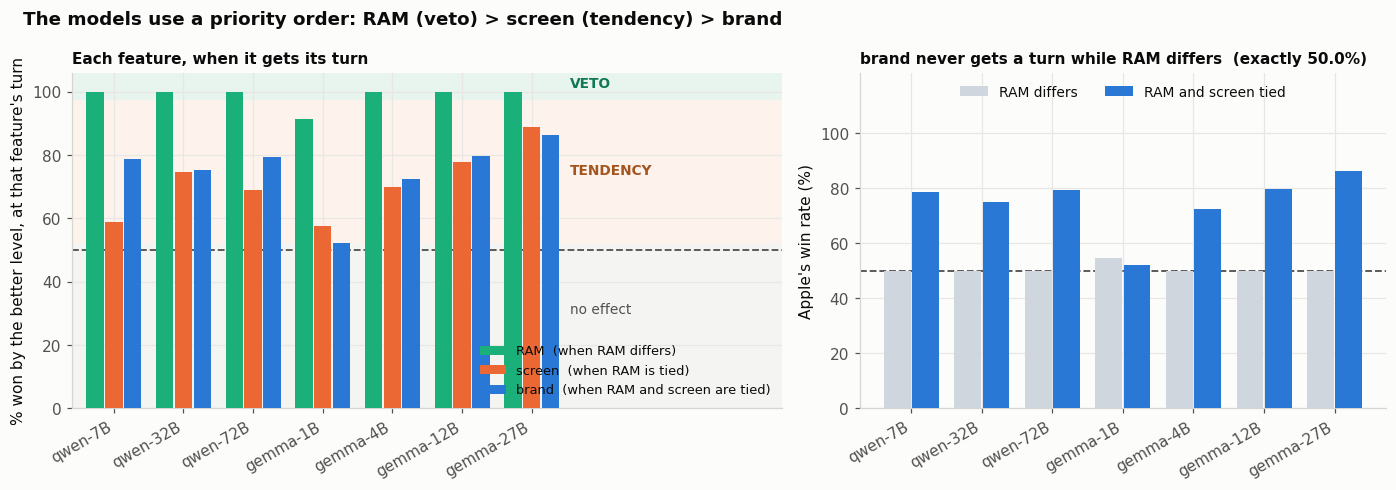

more RAM wins 5 of 7 models at exactly 100% (6750 of 6750 comparisons each)


In [222]:
# Fig 10b.1 - the priority order, measured. Win rates only, no fitted model.
SORD = {"13-inch": 0, "14-inch": 1, "16-inch": 2}
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
    sa, sb = d.a_screen.map(SORD).values, d.b_screen.map(SORD).values
    db = (d.a_brand != d.b_brand).values
    ap = (d.a_brand == "Apple").values
    rows.append(dict(model=lbl(fam, s),
                     ram=winrate(d, ra != rb, ra > rb),
                     screen=winrate(d, (ra == rb) & (sa != sb), sa > sb),
                     brand=winrate(d, (ra == rb) & (sa == sb) & db, ap),
                     brand_when_ram_differs=winrate(d, (ra != rb) & db, ap)))
DEC = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5),
                         gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
x = np.arange(len(DEC))
ax.axhspan(97, 106, color="#e8f4ee", zorder=0)
ax.axhspan(52, 97, color="#fdf3ec", zorder=0)
ax.axhspan(0, 52, color="#f4f4f2", zorder=0)
for i, (c, lab) in enumerate([("ram", "RAM  (when RAM differs)"),
                              ("screen", "screen  (when RAM is tied)"),
                              ("brand", "brand  (when RAM and screen are tied)")]):
    ax.bar(x + (i - 1) * .27, DEC[c], .25, color=FEATURE_COLOR[c], label=lab, zorder=3)
ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2, zorder=2)
ax.text(len(DEC) - .45, 101.5, "VETO", fontsize=9, color="#0f7a52", fontweight="bold")
ax.text(len(DEC) - .45, 74, "TENDENCY", fontsize=9, color="#a4551f", fontweight="bold")
ax.text(len(DEC) - .45, 30, "no effect", fontsize=9, color=INK_MUTED)
ax.set_xlim(-.6, len(DEC) + 2.6)
ax.set_ylim(0, 106)
ax.set_xticks(x, DEC.model, rotation=30, ha="right")
ax.set_ylabel("% won by the better level, at that feature's turn")
ax.set_title("Each feature, when it gets its turn", loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", zorder=1)

ax = axes[1]
ax.bar(x - .2, DEC.brand_when_ram_differs, .38, color="#cfd6de",
       label="RAM differs", zorder=3)
ax.bar(x + .2, DEC.brand, .38, color=FEATURE_COLOR["brand"],
       label="RAM and screen tied", zorder=3)
ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
ax.set_xticks(x, DEC.model, rotation=30, ha="right")
ax.set_ylim(0, 122)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel("Apple's win rate (%)")
ax.set_title("brand never gets a turn while RAM differs  (exactly 50.0%)",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=2,
          bbox_to_anchor=(.5, 1.0))
fig.suptitle("The models use a priority order: RAM (veto) > screen (tendency) > brand",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "s10b_priority")
plt.show()
print("more RAM wins", int(DEC.ram.eq(100).sum()), "of 7 models at exactly 100% "
      "(6750 of 6750 comparisons each)")

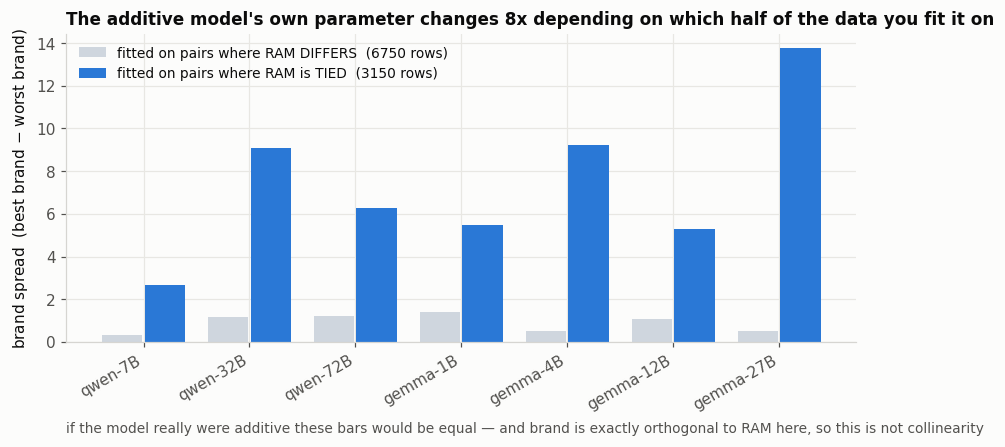

mean spread: RAM differs 0.88   RAM tied 7.39   ratio 8.4x


In [223]:
# Fig 10b.2 - the cleanest falsification of additivity.
# Fit the brand weights TWICE on the same run: once on the pairs where RAM differs,
# once on the pairs where RAM is tied. A sum of separate parts must give the same answer.
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    dif, tie = d[(d.a_ram != d.b_ram).values], d[(d.a_ram == d.b_ram).values]
    bd = bvec(fit_bt(dif))
    bt = bvec(fit_bt(tie, ("brand", "screen")))
    rows.append(dict(model=lbl(fam, s),
                     differs=bd.max() - bd.min(), tied=bt.max() - bt.min()))
SPL = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.2, 4.3))
x = np.arange(len(SPL))
ax.bar(x - .2, SPL.differs, .38, color="#cfd6de",
       label="fitted on pairs where RAM DIFFERS  (6750 rows)")
ax.bar(x + .2, SPL.tied, .38, color=FEATURE_COLOR["brand"],
       label="fitted on pairs where RAM is TIED  (3150 rows)")
ax.set_xticks(x, SPL.model, rotation=30, ha="right")
ax.set_ylabel("brand spread  (best brand $-$ worst brand)")
ax.legend(frameon=False, fontsize=9)
ax.set_title("The additive model's own parameter changes 8x depending on which half "
             "of the data you fit it on", loc="left", fontweight="bold", fontsize=11)
ax.text(0, -.26, "if the model really were additive these bars would be equal — and brand "
        "is exactly orthogonal to RAM here, so this is not collinearity",
        transform=ax.transAxes, fontsize=9, color=INK_MUTED, va="top")
fig.tight_layout()
save(fig, "s10b_additivity_broken")
plt.show()
print(f"mean spread: RAM differs {SPL.differs.mean():.2f}   RAM tied {SPL.tied.mean():.2f}"
      f"   ratio {SPL.tied.mean()/SPL.differs.mean():.1f}x")

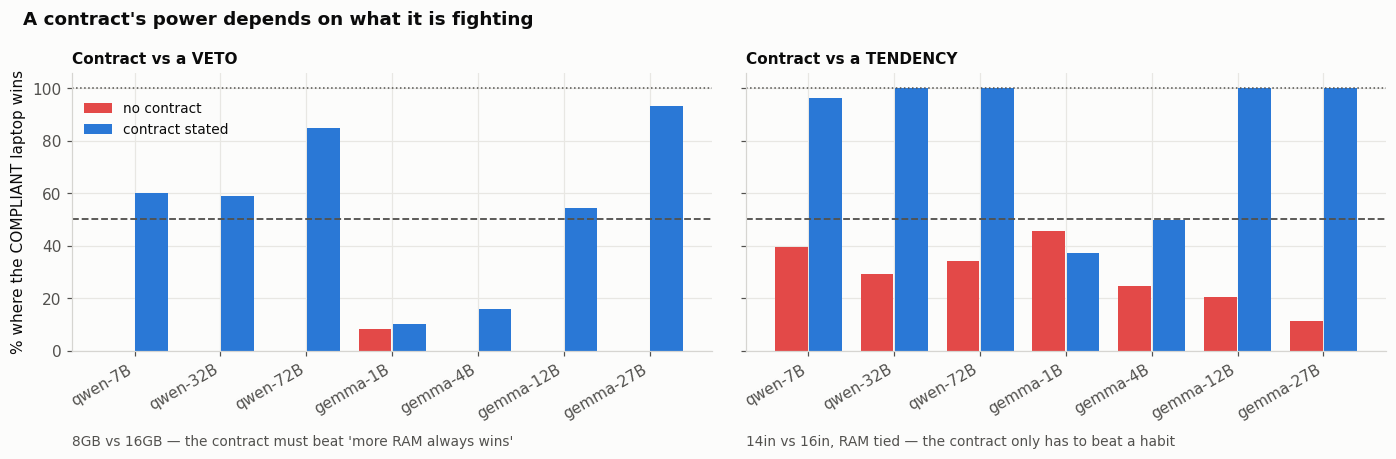

control — where the contract is SILENT (4GB vs 16GB, neither complies), the RAM veto is untouched:
    model  control
  qwen-7B    100.0
 qwen-32B    100.0
 qwen-72B     97.1
 gemma-1B     98.7
 gemma-4B    100.0
gemma-12B    100.0
gemma-27B    100.0


In [224]:
# Fig 10b.3 - a contract beats a TENDENCY completely, a VETO only partly.
# The conflict pairs, where the contract and the model's own order disagree:
#   ram contract    -> 8GB (complies) vs 16GB (more RAM)
#   screen contract -> 14in (complies) vs 16in (bigger), RAM held tied
def pair_on(d, u, v, col):
    return (((d[f"a_{col}"] == u) & (d[f"b_{col}"] == v))
            | ((d[f"a_{col}"] == v) & (d[f"b_{col}"] == u))).values

ramT, scrT = [], []
for fam, s in REAL:
    rr = {"model": lbl(fam, s)}
    for lab, key in [("no contract", "none"), ("contract stated", "ram=8GB")]:
        d = RUNS[(fam, s, key)]
        rr[lab] = winrate(d, pair_on(d, "8GB", "16GB", "ram"), (d.a_ram == "8GB").values)
    d = RUNS[(fam, s, "ram=8GB")]
    rr["control"] = winrate(d, pair_on(d, "4GB", "16GB", "ram"), (d.a_ram == "16GB").values)
    ramT.append(rr)
    sr = {"model": lbl(fam, s)}
    for lab, key in [("no contract", "none"), ("contract stated", "screen=14-inch")]:
        d = RUNS[(fam, s, key)]
        m = pair_on(d, "14-inch", "16-inch", "screen") & (d.a_ram == d.b_ram).values
        sr[lab] = winrate(d, m, (d.a_screen == "14-inch").values)
    scrT.append(sr)
RAMC, SCRC = pd.DataFrame(ramT), pd.DataFrame(scrT)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), sharey=True)
for ax, (T, title, note) in zip(axes, [
        (RAMC, "Contract vs a VETO",
         "8GB vs 16GB — the contract must beat 'more RAM always wins'"),
        (SCRC, "Contract vs a TENDENCY",
         "14in vs 16in, RAM tied — the contract only has to beat a habit")]):
    x = np.arange(len(T))
    ax.bar(x - .2, T["no contract"], .38, color=VIOLATE, label="no contract")
    ax.bar(x + .2, T["contract stated"], .38, color=SATISFY, label="contract stated")
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1.2)
    ax.axhline(100, color=INK_MUTED, ls=":", lw=1)
    ax.set_xticks(x, T.model, rotation=30, ha="right")
    ax.set_ylim(0, 106)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10)
    ax.text(0, -.30, note, transform=ax.transAxes, fontsize=9, color=INK_MUTED, va="top")
axes[0].set_ylabel("% where the COMPLIANT laptop wins")
axes[0].legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(0, .94))
fig.suptitle("A contract's power depends on what it is fighting", x=.02, ha="left",
             fontweight="bold")
fig.tight_layout()
save(fig, "s10b_contract_power")
plt.show()
print("control — where the contract is SILENT (4GB vs 16GB, neither complies), "
      "the RAM veto is untouched:")
print(RAMC[["model", "control"]].round(1).to_string(index=False))

---
# Slide 11 — Read it as contract theory

The contract does not overwrite the agent's utility `v`. It makes `v` **conditional on
compliance**.

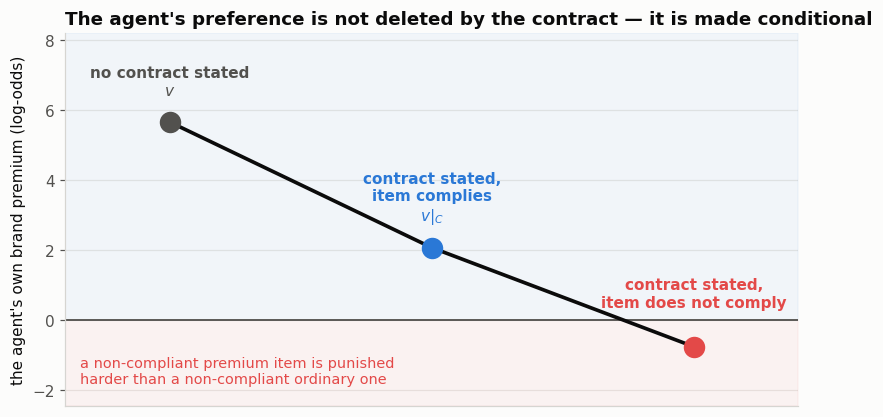

In [225]:
# Fig 11.1 - the schematic version of slide 10, for the argument rather than the evidence.
fig, ax = plt.subplots(figsize=(8.6, 4.4))
xs = [0, 1, 2]
ys = [E[E.con == "none"].apple.mean(), sub[sub.sat].apple.mean(), sub[~sub.sat].apple.mean()]
ax.plot(xs, ys, "-o", color=INK, lw=2.4, ms=10, zorder=3)
for x, y, c, t, dy in zip(xs, ys, [GAMMA_C, SATISFY, VIOLATE],
                          ["no contract stated\n$v$",
                           "contract stated,\nitem complies\n$v|_C$",
                           "contract stated,\nitem does not comply"], [18, 18, 26]):
    ax.scatter([x], [y], s=170, color=c, zorder=4)
    ax.annotate(t, (x, y), textcoords="offset points", xytext=(0, dy),
                ha="center", fontsize=10, color=c, fontweight="bold")
ax.axhline(0, color=INK_MUTED, lw=1.2)
top, bot = max(ys) * 1.45, min(ys) * 3.2
ax.fill_between([-.4, 2.4], 0, top, color=SATISFY, alpha=.05)
ax.fill_between([-.4, 2.4], bot, 0, color=VIOLATE, alpha=.05)
ax.set_xlim(-.4, 2.4); ax.set_ylim(bot, top); ax.set_xticks([])
ax.set_ylabel("the agent's own brand premium (log-odds)")
ax.set_title("The agent's preference is not deleted by the contract — it is made conditional",
             loc="left", fontweight="bold")
ax.text(.02, .06, "a non-compliant premium item is punished\n"
        "harder than a non-compliant ordinary one",
        transform=ax.transAxes, ha="left", fontsize=9.5, color=VIOLATE)
save(fig, "s11_contract_reading")
plt.show()

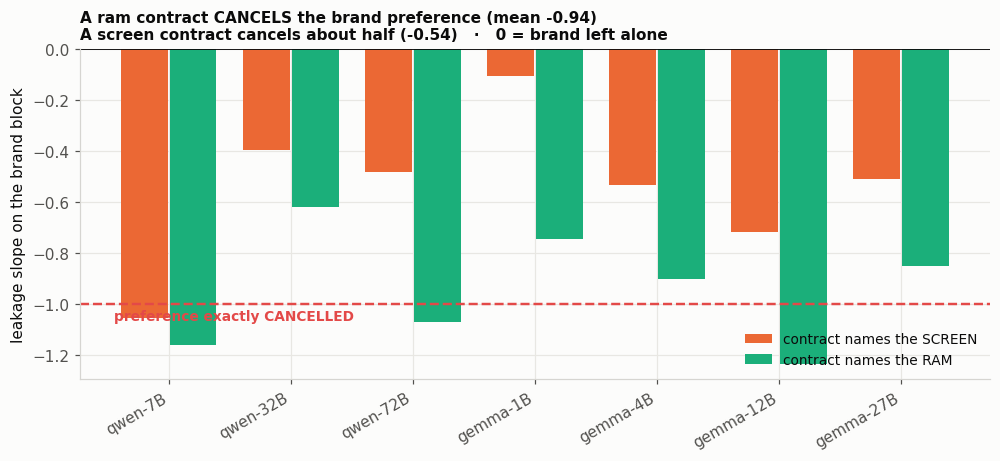

    model  screen contract  ram contract
  qwen-7B            -1.06         -1.16
 qwen-32B            -0.40         -0.62
 qwen-72B            -0.49         -1.07
 gemma-1B            -0.11         -0.75
 gemma-4B            -0.53         -0.90
gemma-12B            -0.72         -1.24
gemma-27B            -0.51         -0.85


In [226]:
# Fig 11.2 - the contract-theory number: how much of the brand preference does a
# contract CANCEL?  Slope of the change in the brand block on the no-contract brand block,
# both sum-to-zero, so it is gauge-safe and scale-free:
#     slope = (w_contract - w_none) . w_none / (w_none . w_none)
#      0  = the contract leaves brand alone
#     -1  = the contract exactly cancels the brand preference
# Fitted on the spec-tied stratum, where brand is the operative feature (slide 10b).
# This equals the off-diagonal (leakage) block of the GRUM in grum.ipynb - verified to 2dp.
def tied_pairs(d):
    return d[((d.a_screen == d.b_screen) & (d.a_ram == d.b_ram)).values]

rows = []
for fam, s in REAL:
    d0 = bvec(fit_bt(tied_pairs(RUNS[(fam, s, "none")]), ("brand",)))
    r = {"model": lbl(fam, s)}
    for key, lab in [("screen=14-inch", "screen contract"), ("ram=8GB", "ram contract")]:
        d1 = bvec(fit_bt(tied_pairs(RUNS[(fam, s, key)]), ("brand",)))
        r[lab] = float((d1 - d0) @ d0 / (d0 @ d0))
    rows.append(r)
LK = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.2, 4.3))
x = np.arange(len(LK))
ax.bar(x - .2, LK["screen contract"], .38, color=FEATURE_COLOR["screen"],
       label="contract names the SCREEN")
ax.bar(x + .2, LK["ram contract"], .38, color=FEATURE_COLOR["ram"],
       label="contract names the RAM")
ax.axhline(0, color=INK, lw=1.2)
ax.axhline(-1, color=VIOLATE, ls="--", lw=1.6)
ax.text(-.45, -1.02, "preference exactly CANCELLED", color=VIOLATE, fontsize=9,
        va="top", ha="left", fontweight="bold")
ax.set_xticks(x, LK.model, rotation=30, ha="right")
ax.set_ylabel("leakage slope on the brand block")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title(f"A ram contract CANCELS the brand preference (mean "
             f"{LK['ram contract'].mean():.2f})\n"
             f"A screen contract cancels about half ({LK['screen contract'].mean():.2f})"
             f"   ·   0 = brand left alone",
             loc="left", fontweight="bold", fontsize=10)
fig.tight_layout()
save(fig, "s11_leakage")
plt.show()
print(LK.round(2).to_string(index=False))

---
# Slide 12 — Method health

Three numbers that change how every result above should be read.

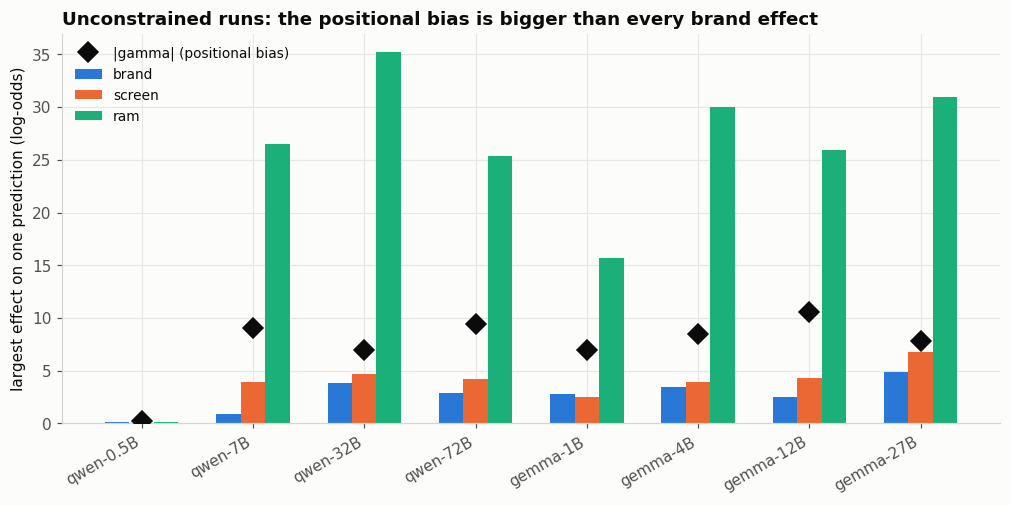

In [227]:
# Fig 12.1 - the positional bias against the thing we are trying to measure.
rows = []
for fam, s in ALL:
    for c in CON:
        w = W[(fam, s, c)]
        for f in LEVELS:
            v = fvec(w, f)
            rows.append(dict(model=lbl(fam, s), con=CLAB[c], feature=f,
                             rng=v.max() - v.min()))
        rows.append(dict(model=lbl(fam, s), con=CLAB[c], feature="|gamma|",
                         rng=abs(w["gamma"])))
R = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 4.6))
piv = R[R.con == "none"].pivot(index="model", columns="feature", values="rng").reindex(
    [lbl(f, s) for f, s in ALL])
x = np.arange(len(piv))
for i, (f, c) in enumerate([("brand", FEATURE_COLOR["brand"]),
                            ("screen", FEATURE_COLOR["screen"]),
                            ("ram", FEATURE_COLOR["ram"])]):
    ax.bar(x + (i - 1) * .22, piv[f], .22, color=c, label=f)
ax.plot(x, piv["|gamma|"], "D", color=INK, ms=9, label="|gamma| (positional bias)", zorder=4)
ax.set_xticks(x, piv.index, rotation=30, ha="right")
ax.set_ylabel("largest effect on one prediction (log-odds)")
ax.set_title("Unconstrained runs: the positional bias is bigger than every brand effect",
             loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
save(fig, "s12_gamma_vs_features")
plt.show()

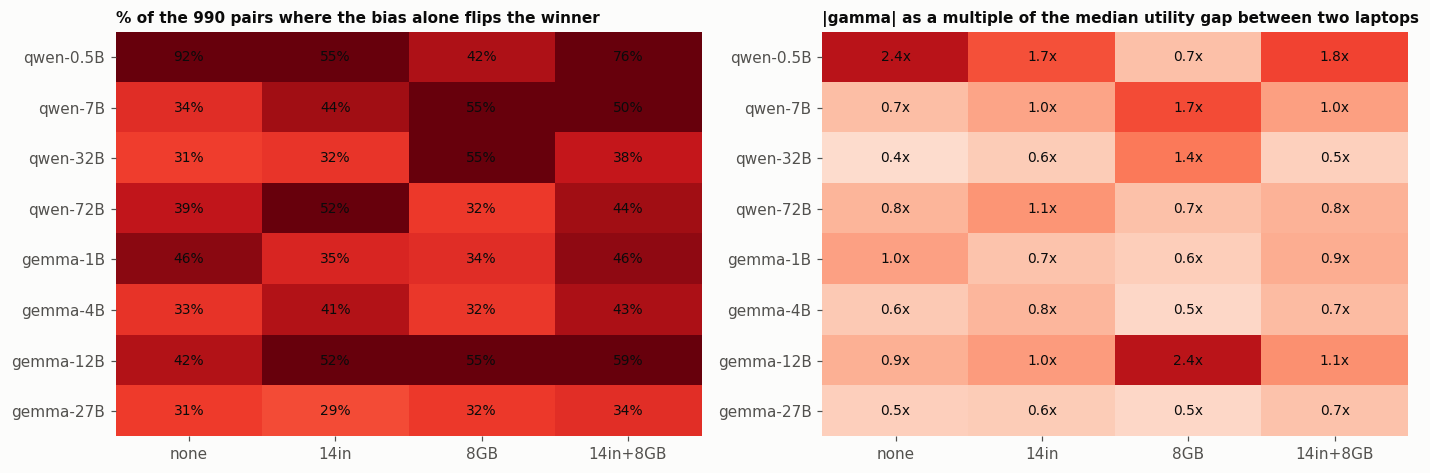

In [228]:
# Fig 12.2 - how often does the bias alone decide the winner?
rows = []
for fam, s in ALL:
    for c in CON:
        w = W[(fam, s, c)]
        u = np.array(list(item_utils(w).values()))
        du = np.abs(u[:, None] - u[None, :])[np.triu_indices(45, 1)]
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         flip=100 * float((du < abs(w["gamma"])).mean()),
                         ratio=abs(w["gamma"]) / np.median(du)))
FL = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
piv = FL.pivot(index="model", columns="con", values="flip").reindex(
    [lbl(f, s) for f, s in ALL])[cols]
im = axes[0].imshow(piv.values, cmap="Reds", vmin=0, vmax=50, aspect="auto")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f"{piv.values[i, j]:.0f}%", ha="center", va="center", fontsize=9)
axes[0].set_xticks(range(4), cols); axes[0].set_yticks(range(len(piv)), piv.index)
axes[0].set_title("% of the 990 pairs where the bias alone flips the winner",
                  loc="left", fontweight="bold", fontsize=10)
axes[0].grid(False)
for sp in axes[0].spines.values():
    sp.set_visible(False)

pr = FL.pivot(index="model", columns="con", values="ratio").reindex(piv.index)[cols]
axes[1].imshow(pr.values, cmap="Reds", vmin=0, vmax=3, aspect="auto")
for i in range(pr.shape[0]):
    for j in range(pr.shape[1]):
        axes[1].text(j, i, f"{pr.values[i, j]:.1f}x", ha="center", va="center", fontsize=9)
axes[1].set_xticks(range(4), cols); axes[1].set_yticks(range(len(pr)), pr.index)
axes[1].set_title("|gamma| as a multiple of the median utility gap between two laptops",
                  loc="left", fontweight="bold", fontsize=10)
axes[1].grid(False)
for sp in axes[1].spines.values():
    sp.set_visible(False)
fig.tight_layout()
save(fig, "s12_bias_flips")
plt.show()

/tmp/ipykernel_1276977/919390525.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([piv.loc[m].values for m in piv.index], labels=piv.index,


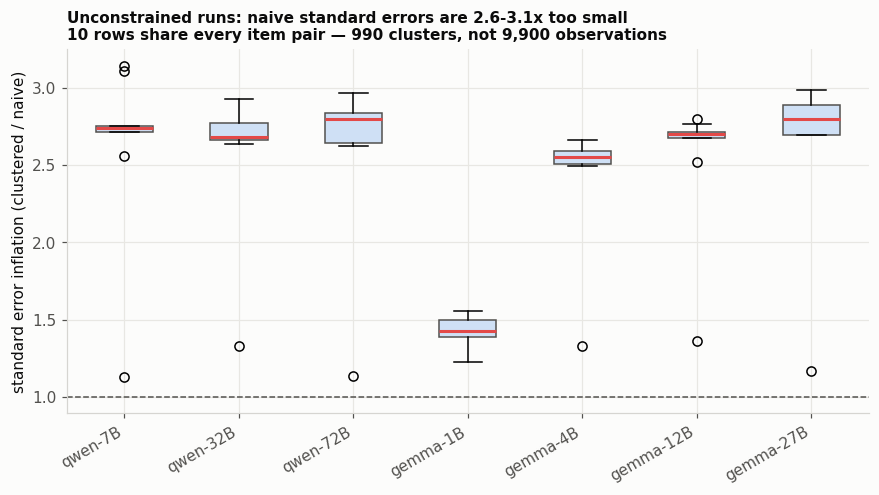

model
gemma-12B    2.55
gemma-1B     1.43
gemma-27B    2.64
gemma-4B     2.43
qwen-32B     2.58
qwen-72B     2.61
qwen-7B      2.62
Name: infl, dtype: float64


In [229]:
# Fig 12.3 - the p-values overstate confidence. Cluster by unordered pair.
rows = []
for fam, s in REAL:
    df = RUNS[(fam, s, "none")]
    y = (df.score_a - df.score_b).values
    cs, names = [np.ones(len(df))], ["gamma"]
    for f in LEVELS:
        for l in LEVELS[f][1:]:
            cs.append((df["a_" + f].values == l).astype(float)
                      - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cs)
    la = (df.a_brand + "-" + df.a_screen + "-" + df.a_ram).values.astype(str)
    lb = (df.b_brand + "-" + df.b_screen + "-" + df.b_ram).values.astype(str)
    pid = pd.Series(np.char.add(np.char.add(np.minimum(la, lb), "|"),
                                np.maximum(la, lb))).astype("category").cat.codes
    o = sm.OLS(y, X).fit()
    cl = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": pid})
    for n, a, b in zip(names, o.bse, cl.bse):
        rows.append(dict(model=lbl(fam, s), term=n, infl=b / a))
S = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.4, 4.3))
piv = S.pivot_table(index="model", columns="term", values="infl").reindex(
    [lbl(f, s) for f, s in REAL])
ax.boxplot([piv.loc[m].values for m in piv.index], labels=piv.index,
           patch_artist=True,
           boxprops=dict(facecolor="#cfe0f5", edgecolor=INK_MUTED),
           medianprops=dict(color=VIOLATE, lw=2))
ax.axhline(1, color=INK_MUTED, lw=1, ls="--")
ax.set_ylabel("standard error inflation (clustered / naive)")
ax.set_title("Unconstrained runs: naive standard errors are 2.6-3.1x too small\n"
             "10 rows share every item pair — 990 clusters, not 9,900 observations",
             loc="left", fontweight="bold", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save(fig, "s12_se_inflation")
plt.show()
print(S.groupby("model")["infl"].mean().round(2))

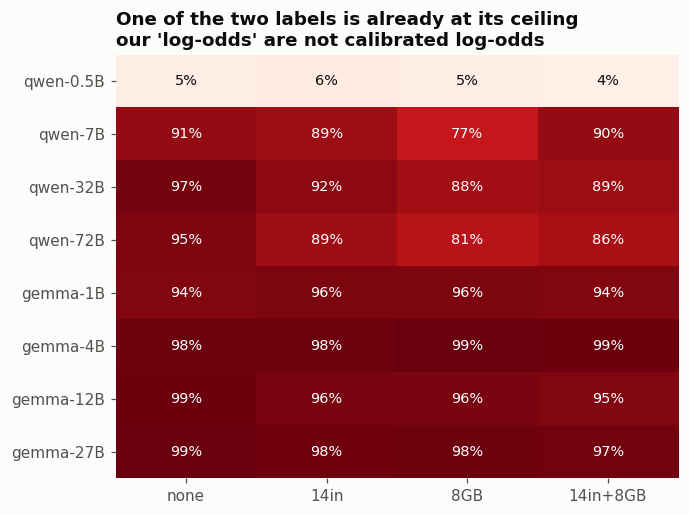

In [230]:
# Fig 12.4 - saturation: the measurement is at its ceiling almost everywhere.
rows = []
for k, d in RUNS.items():
    for t, dd in d.groupby("template_idx"):
        ca, cb = dd.score_a.max(), dd.score_b.max()
        rows.append(dict(model=lbl(k[0], k[1]), con=CLAB[k[2]],
                         either=100 * float(((dd.score_a > ca - .05)
                                             | (dd.score_b > cb - .05)).mean())))
SAT = pd.DataFrame(rows)
piv = SAT.pivot_table(index="model", columns="con", values="either").reindex(
    [lbl(f, s) for f, s in ALL])[cols]

fig, ax = plt.subplots(figsize=(6.6, 5))
im = ax.imshow(piv.values, cmap="Reds", vmin=0, vmax=100, aspect="auto")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9.5,
                color="white" if v > 60 else INK)
ax.set_xticks(range(4), cols); ax.set_yticks(range(len(piv)), piv.index)
ax.set_title("One of the two labels is already at its ceiling\n"
             "our 'log-odds' are not calibrated log-odds", loc="left", fontweight="bold")
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
save(fig, "s12_saturation")
plt.show()

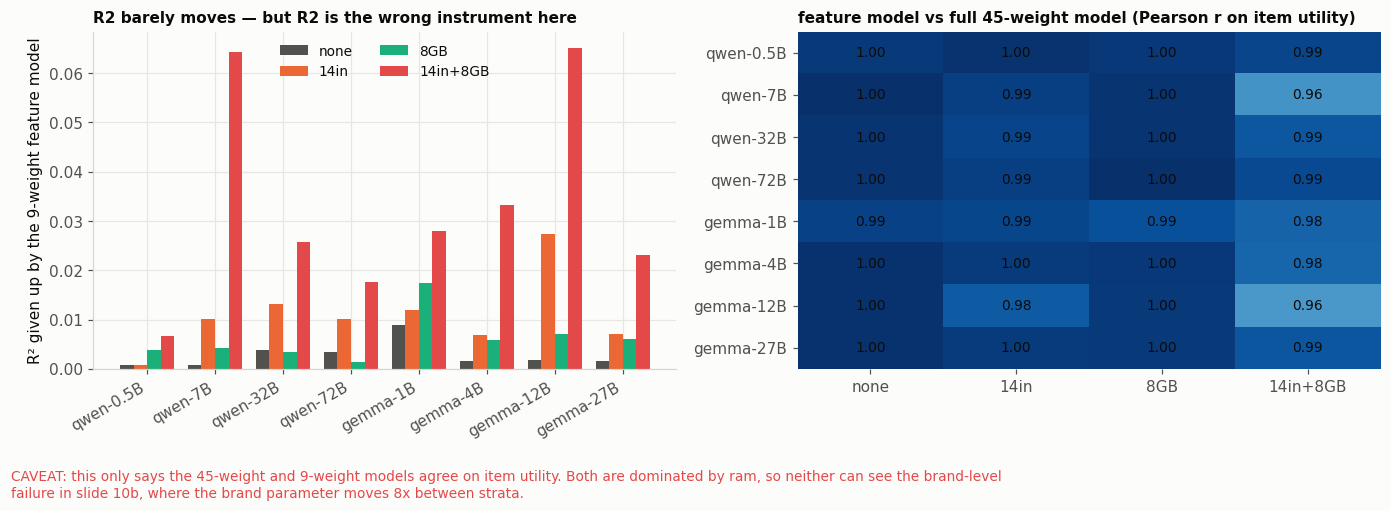

In [231]:
# Fig 12.5 - a diagnostic that CANNOT see the additivity failure. Kept as a caveat.
# The 45-weight full model and the 9-weight feature model agree on item utility, so it
# looks like additivity holds. It does not: R2 is dominated by ram, and a brand x ram
# interaction moves R2 by almost nothing. Slide 10b shows the failure this misses.
rows = []
for fam, s in ALL:
    for c in CON:
        w, fu = W[(fam, s, c)], FULL[(fam, s, c)]
        uf = item_utils(w)
        keys = list(uf)
        a = np.array([uf[k] for k in keys])
        b = np.array([fu["u"]["-".join(k)] for k in keys])
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         r=np.corrcoef(a, b)[0, 1], gap=fu["r2"] - w["r2"]))
AD = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))
piv = AD.pivot(index="model", columns="con", values="gap").reindex(
    [lbl(f, s) for f, s in ALL])[cols]
x = np.arange(len(piv))
for i, c in enumerate(cols):
    axes[0].bar(x + (i - 1.5) * .2, piv[c], .2,
                color=[GAMMA_C, FEATURE_COLOR["screen"], FEATURE_COLOR["ram"], VIOLATE][i],
                label=c)
axes[0].set_xticks(x, piv.index, rotation=30, ha="right")
axes[0].set_ylabel("R² given up by the 9-weight feature model")
axes[0].set_title("R2 barely moves — but R2 is the wrong instrument here",
                  loc="left", fontweight="bold", fontsize=10)
axes[0].legend(frameon=False, fontsize=9, ncol=2)

pr = AD.pivot(index="model", columns="con", values="r").reindex(piv.index)[cols]
axes[1].imshow(pr.values, cmap="Blues", vmin=.9, vmax=1, aspect="auto")
for i in range(pr.shape[0]):
    for j in range(pr.shape[1]):
        axes[1].text(j, i, f"{pr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
axes[1].set_xticks(range(4), cols); axes[1].set_yticks(range(len(pr)), pr.index)
axes[1].set_title("feature model vs full 45-weight model (Pearson r on item utility)",
                  loc="left", fontweight="bold", fontsize=10)
axes[1].grid(False)
for sp in axes[1].spines.values():
    sp.set_visible(False)
fig.text(0, -.03, "CAVEAT: this only says the 45-weight and 9-weight models agree on "
         "item utility. Both are dominated by ram, so neither can see the brand-level\n"
         "failure in slide 10b, where the brand parameter moves 8x between strata.",
         fontsize=9, color=VIOLATE, va="top")
fig.tight_layout()
save(fig, "s12_additivity")
plt.show()

---
# Slide 13 — What we still cannot measure

Deck 3 made the **welfare gap** `ΔW(x) = u(x_opt) − u(x)` the headline metric of Aim 2.
We have never defined a user utility `u` for the laptops set, so ΔW has never been
computed. What we *can* compute today is the other half of deck 3's definition:
**robustness**, `{i : x*_i = y_i}` — does the agent's own top choice comply?

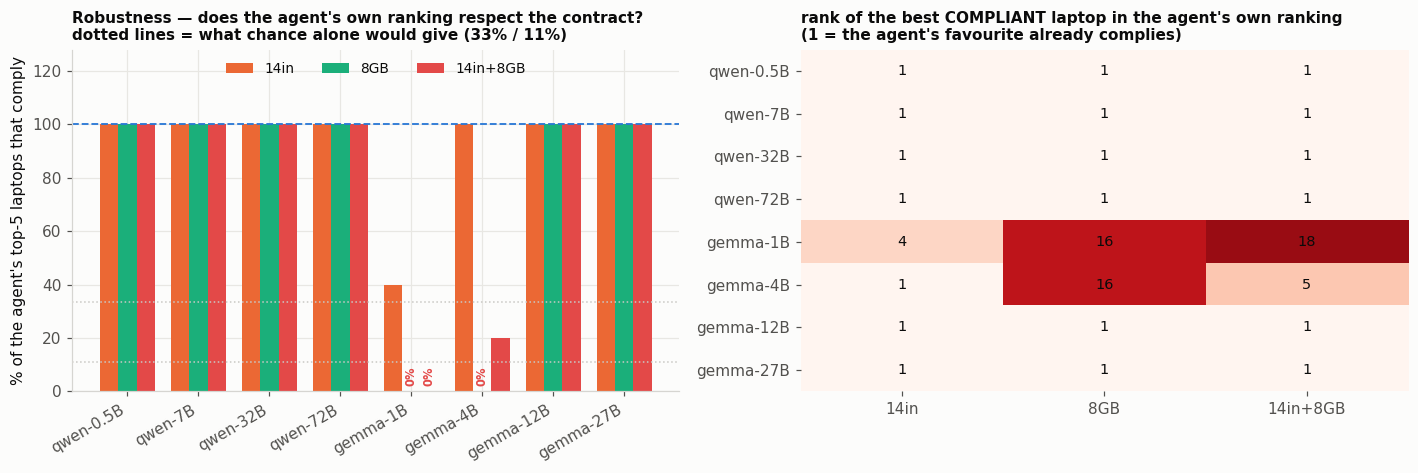

    model      con  top1  top5  best_rank  n_feasible
qwen-0.5B     14in 100.0 100.0          1          15
qwen-0.5B      8GB 100.0 100.0          1          15
qwen-0.5B 14in+8GB 100.0 100.0          1           5
  qwen-7B     14in 100.0 100.0          1          15
  qwen-7B      8GB 100.0 100.0          1          15
  qwen-7B 14in+8GB 100.0 100.0          1           5
 qwen-32B     14in 100.0 100.0          1          15
 qwen-32B      8GB 100.0 100.0          1          15
 qwen-32B 14in+8GB 100.0 100.0          1           5
 qwen-72B     14in 100.0 100.0          1          15
 qwen-72B      8GB 100.0 100.0          1          15
 qwen-72B 14in+8GB 100.0 100.0          1           5
 gemma-1B     14in   0.0  40.0          4          15
 gemma-1B      8GB   0.0   0.0         16          15
 gemma-1B 14in+8GB   0.0   0.0         18           5
 gemma-4B     14in 100.0 100.0          1          15
 gemma-4B      8GB   0.0   0.0         16          15
 gemma-4B 14in+8GB   0.0  20

In [232]:
# Fig 13.1 - does the agent's argmax comply with the contract it was given?
rows = []
for fam, s in ALL:
    for c in CON[1:]:
        w = W[(fam, s, c)]
        con = CONSTRAINTS[(fam, s, c)]
        uf = item_utils(w)
        ranked = sorted(uf, key=uf.get, reverse=True)
        ok = [satisfies(con, screen=k[1], ram=k[2]) for k in ranked]
        n_ok = sum(ok)
        rows.append(dict(model=lbl(fam, s), con=CLAB[c],
                         top1=100 * float(ok[0]),
                         top5=100 * float(np.mean(ok[:5])),
                         best_rank=1 + ok.index(True),
                         n_feasible=n_ok))
RB = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
piv = RB.pivot(index="model", columns="con", values="top5").reindex(
    [lbl(f, s) for f, s in ALL])[cols[1:]]
x = np.arange(len(piv))
for i, c in enumerate(cols[1:]):
    off = (i - 1) * .26
    axes[0].bar(x + off, piv[c], .26,
                color=[FEATURE_COLOR["screen"], FEATURE_COLOR["ram"], VIOLATE][i], label=c)
    for xi, v in zip(x, piv[c]):          # a 0% bar is invisible - say so explicitly
        if v == 0:
            axes[0].text(xi + off, 2, "0%", ha="center", fontsize=7.5, color=VIOLATE,
                         rotation=90, va="bottom", fontweight="bold")
axes[0].axhline(100, color=SATISFY, lw=1.2, ls="--")
for frac, c in [(100 * 15 / 45, "#c9c8c4"), (100 * 5 / 45, "#c9c8c4")]:
    axes[0].axhline(frac, color=c, lw=1, ls=":")
axes[0].set_xticks(x, piv.index, rotation=30, ha="right")
axes[0].set_ylim(0, 128)
axes[0].set_ylabel("% of the agent's top-5 laptops that comply")
axes[0].set_title("Robustness — does the agent's own ranking respect the contract?\n"
                  "dotted lines = what chance alone would give (33% / 11%)",
                  loc="left", fontweight="bold", fontsize=10)
axes[0].legend(frameon=False, fontsize=9, ncol=3, loc="upper center")

pv = RB.pivot(index="model", columns="con", values="best_rank").reindex(piv.index)[cols[1:]]
im = axes[1].imshow(pv.values, cmap="Reds", vmin=1, vmax=20, aspect="auto")
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        axes[1].text(j, i, f"{pv.values[i, j]:.0f}", ha="center", va="center", fontsize=9.5)
axes[1].set_xticks(range(3), cols[1:]); axes[1].set_yticks(range(len(pv)), pv.index)
axes[1].set_title("rank of the best COMPLIANT laptop in the agent's own ranking\n"
                  "(1 = the agent's favourite already complies)",
                  loc="left", fontweight="bold", fontsize=10)
axes[1].grid(False)
for sp in axes[1].spines.values():
    sp.set_visible(False)
fig.tight_layout()
save(fig, "s13_robustness")
plt.show()
print(RB.round(1).to_string(index=False))

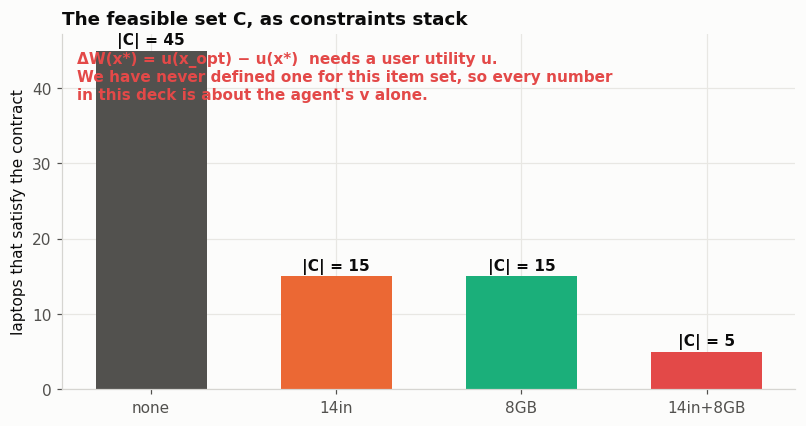

In [233]:
# Fig 13.2 - what ΔW would need. The feasible set shrinks; u is the missing piece.
fig, ax = plt.subplots(figsize=(8.6, 4.2))
sizes_ = [45, 15, 15, 5]
ax.bar(range(4), sizes_, color=[GAMMA_C, FEATURE_COLOR["screen"], FEATURE_COLOR["ram"], VIOLATE],
       width=.6)
for i, v in enumerate(sizes_):
    ax.text(i, v + .8, f"|C| = {v}", ha="center", fontweight="bold")
ax.set_xticks(range(4), cols)
ax.set_ylabel("laptops that satisfy the contract")
ax.set_title("The feasible set C, as constraints stack", loc="left", fontweight="bold")
ax.text(.02, .95, "ΔW(x*) = u(x_opt) − u(x*)  needs a user utility u.\n"
        "We have never defined one for this item set, so every number\n"
        "in this deck is about the agent's v alone.",
        transform=ax.transAxes, va="top", fontsize=10, color=VIOLATE, fontweight="bold")
save(fig, "s13_feasible_set")
plt.show()

---
# Slide 14 — What to run next

The 2x2 of single constraints is half empty, and the frame ladder has never been run.

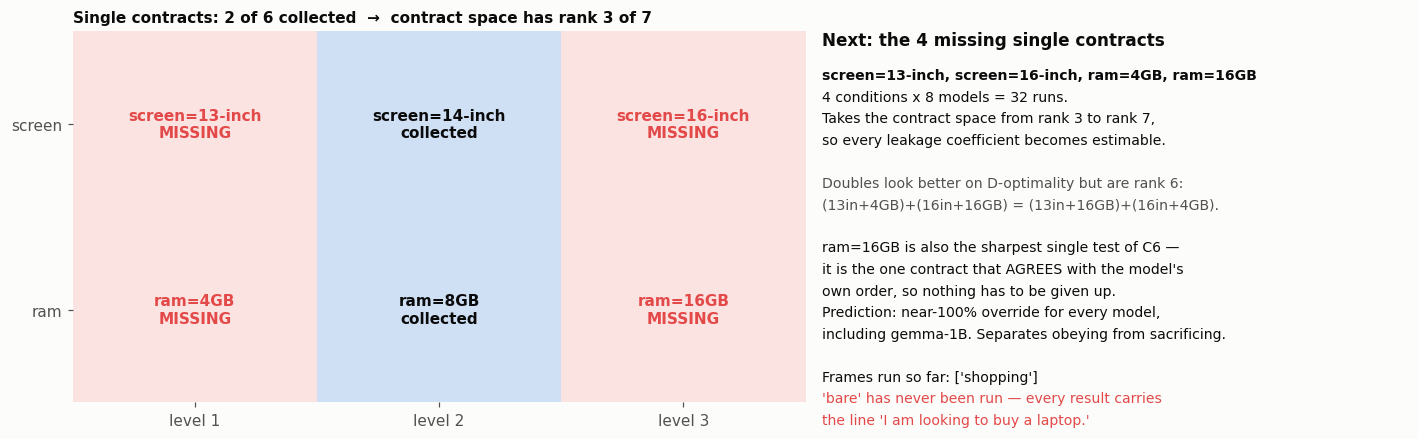

collected constraint ids: ['none', 'ram=8GB', 'ram=8GB+screen=14-inch', 'screen=14-inch']


In [234]:
# Fig 14.1 - what to run next. Superseded 2026-08-10 by the GRUM identification argument:
# the contract space x has rank 3 of 7, and only NEW CONTRACT CONDITIONS can fix that -
# more items or more templates cannot.
have = sorted({k[2] for k in RUNS})
have_frames = {json.load(open(os.path.join(b, r, "config.json")))["frame"]["name"]
               for b in BASE for r in os.listdir(b)
               if os.path.isfile(os.path.join(b, r, "config.json"))}
grid_feats = [("screen", SC), ("ram", RM)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.1),
                         gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
got = np.array([[1 if f"{f}={l}" in have else 0 for l in ls] for f, ls in grid_feats])
ax.imshow(got, cmap=LinearSegmentedColormap.from_list("c", ["#fbe3e2", "#cfe0f5"]),
          vmin=0, vmax=1, aspect="auto")
for i_, (f, ls) in enumerate(grid_feats):
    for j, l in enumerate(ls):
        ok = f"{f}={l}" in have
        ax.text(j, i_, f"{f}={l}\n{'collected' if ok else 'MISSING'}", ha="center",
                va="center", fontsize=10, fontweight="bold", color=INK if ok else VIOLATE)
ax.set_xticks(range(3), ["level 1", "level 2", "level 3"])
ax.set_yticks(range(2), [f for f, _ in grid_feats])
ax.set_title("Single contracts: 2 of 6 collected  →  contract space has rank 3 of 7",
             loc="left", fontweight="bold", fontsize=10)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)

ax = axes[1]
ax.axis("off")
ax.text(0, 1, "Next: the 4 missing single contracts", fontweight="bold", fontsize=11, va="top")
lines = [
    ("screen=13-inch, screen=16-inch, ram=4GB, ram=16GB", INK),
    ("4 conditions x 8 models = 32 runs.", INK),
    ("Takes the contract space from rank 3 to rank 7,", INK),
    ("so every leakage coefficient becomes estimable.", INK),
    ("", INK),
    ("Doubles look better on D-optimality but are rank 6:", INK_MUTED),
    ("(13in+4GB)+(16in+16GB) = (13in+16GB)+(16in+4GB).", INK_MUTED),
    ("", INK),
    ("ram=16GB is also the sharpest single test of C6 —", INK),
    ("it is the one contract that AGREES with the model's", INK),
    ("own order, so nothing has to be given up.", INK),
    ("Prediction: near-100% override for every model,", INK),
    ("including gemma-1B. Separates obeying from sacrificing.", INK),
    ("", INK),
    (f"Frames run so far: {sorted(have_frames)}", INK),
    ("'bare' has never been run — every result carries", VIOLATE),
    ("the line 'I am looking to buy a laptop.'", VIOLATE),
]
for k, (t, col) in enumerate(lines):
    ax.text(0, .90 - k * .058, t, fontsize=9.2, va="top", color=col,
            fontweight="bold" if k == 0 else "normal")
fig.tight_layout()
save(fig, "s14_next_runs")
plt.show()
print("collected constraint ids:", have)

---
## All figures written

`figs/deck5/` now holds one PNG per figure, named `s<slide>_<what>.png`.

In [235]:
for f in sorted(os.listdir(FIGDIR)):
    print(f, f"{os.path.getsize(os.path.join(FIGDIR, f))/1024:.0f}K")

s04_itemset.png 37K
s04_setup.png 131K
s05_adherence_A_smallmultiples.png 212K
s05_adherence_B_lollipop.png 119K
s05_adherence_C_heatmap.png 121K
s05_adherence_D_split.png 137K
s05_adherence_scale.png 177K
s05_adherence_trend.png 249K
s05_dilution.png 89K
s05_override.png 139K
s05_what_moves.png 97K
s06_brand_corr.png 120K
s06_brand_trajectories.png 419K
s07_one_brand.png 212K
s08_modelfree.png 277K
s09_c1_scale.png 239K
s09_c2_rtm.png 88K
s09_c4_premise.png 85K
s09_c5_content.png 100K
s10_c6_grid.png 88K
s10_c6_headline.png 213K
s10_c6_ordinal_cells.png 170K
s10_c6_ordinal_feasible.png 130K
s10_c6_permodel.png 75K
s10b_additivity_broken.png 109K
s10b_contract_power.png 112K
s10b_priority.png 148K
s11_contract_reading.png 95K
s11_leakage.png 103K
s12_additivity.png 200K
s12_bias_flips.png 149K
s12_gamma_vs_features.png 95K
s12_saturation.png 103K
s12_se_inflation.png 93K
s13_feasible_set.png 72K
s13_robustness.png 154K
s14_next_runs.png 181K
